## Deteksi Permukaan Licin dan Kasar pada Robot Sony AIBO Menggunakan KNN

## Business Undestanding

### Latar Belakang
Robot zaman sekarang sudah makin pintar, tapi tetap punya satu kelemahan dimana dia belum mengetahui jenis permukaan yang sedang diinjaknya.

Setiap permukaan memberi pola getaran yang berbeda:

- karpet → empuk, menyerap getaran

- Keramik → licin, getaran cepat memantul

- Kayu → keras tapi tidak licin

Dimana jika robot salah menilai permukaan, yang akan terjadi bisa bermacam-macam yaitu bisa mudah selip, gerakannya tidak stabil,navigasi meleset, bahkan komponen robot cepat aus.

Dimana sekarang AIBO punya sensor canggih yang merekam getaran setiap kali langkahnya menyentuh lantai. Dimana satu langkah AIBO direkam sebagai 65 titik getaran, bukan satu angka. Setiap titik mewakili kekuatan getaran pada satu detik atau momen tertentu saat kaki menapak. Bisa dibayangkan, setiap langkah adalah “cerita langkah robot” dalam 65 catatan kecil. Dari pola ini, kita bisa mengajari robot untuk mengenali permukaan yang diinjak.

Sensor Internal AIBO

Pada robot Sony AIBO tidak ada alat eksternal tambahan untuk mengukur getaran. Semua data diperoleh dari:

1. Accelerometer internal (IMU)

    - Mengukur percepatan dan getaran kaki robot.

    - mengambil satu sumbu: X

    - Bekerja dengan frekuensi sampling tinggi sehingga mampu menangkap perubahan getaran dengan presisi.

Dataset SonyAIBORobotSurface2 berisi data time series satu dimensi dari sensor akselerometer robot AIBO. Data direkam tanpa timestamp eksplisit, kemudian disegmentasi menjadi siklus langkah berdurasi sekitar 0,5 detik dengan panjang 65 sampel. Seluruh data memiliki panjang yang sama dan tidak mengandung nilai hilang. Setiap time series diberi label kelas yang merepresentasikan jenis permukaan lantai.

Data getaran diperoleh dari sensor accelerometer internal yang terdapat pada robot Sony AIBO. Sensor ini merekam sinyal getaran kaki robot selama setiap langkah saat berjalan di permukaan lantai kasar dan licin. Setiap rekaman disampling menjadi 65 titik data yang merepresentasikan karakteristik permukaan lantai, dan setiap sampel diberi label sesuai jenis permukaan.

### Masalah yang dihadapi

Saat ini, robot AIBO belum punya model untuk mendeteksi permukaan secara otomatis. Akibatnya:

1. Robot tidak bisa menyesuaikan kecepatan atau cara jalan sesuai kondisi lantai.

2. Robot tidak tahu kapan permukaan berubah.

3. Navigasi jadi kurang akurat dan terkadang membahayakan.

4. Risiko kerusakan meningkat karena gerakan yang tidak sesuai dengan permukaan.

Dengan kata lain, robot berjalan “buta sensorik” meskipun data sensornya sebenarnya sudah tersedia.

### Tujuan Proyek

Tujuan proyek ini adalah:

1. Mengklasifikasikan jenis permukaan berdasarkan sinyal getaran robot (time series 1D). 
    - Model dilatih untuk mengenali pola 65 titik getaran dalam satu langkah sebagai permukaan tertentu.

2. Membuat robot bergerak lebih aman dan efisien. 
    - Robot bisa menyesuaikan langkah sesuai kondisi lantai (licin → pelan, kasar → stabil).

3. Membangun aplikasi Streamlit sederhana.
    - Dimana aplikasinya Bisa upload data baru, melihat grafik getaran, dan memprediksi permukaan secara langsung.

Dimana dengan cara ini, AIBO belajar "membaca bahasa getaran permukaan" dari langkahnya sendiri.

### Ruang Lingkup Proyek

Hal-hal yang dilakukan di proyek ini:

1. Menggunakan dataset SonyAIBORobotSurface2.

2. Fokus pada klasifikasi time series 1 dimensi.

3. Menerapkan tahap CRISP-DM dari awal sampai deployment:
EDA → preprocessing → modeling → evaluasi → deploy Streamlit.

4. Model yang diuji meliputi KNN, Random Forest, SVM, dan jika perlu CNN 1D.

### Indikator Keberhasilan

Supaya proyek ini dianggap berhasil, targetnya:

Secara teknis:

- Akurasi model minimal 80%.

- Confusion matrix stabil di semua kelas.

- Aplikasi Streamlit berjalan lancar.

Secara fungsional:

- Robot bisa mengenali permukaan secara cepat dan akurat.

- Navigasi robot menjadi lebih aman.

- Risiko slip atau kerusakan bisa dikurangi.

## Data Understanding

## Exploratory Data Analysis (EDA)

### Import Library + Helper Function

In [1]:
# BLOK 1: Imports + helper functions
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import joblib


plt.style.use("ggplot")
sns.set_context("talk")

def read_ts_file(filepath):
    """
    Simple .ts parser for UEA/UCR format.
    Returns: metadata(dict), X(np.ndarray shape=(n_samples, series_length)), y(np.ndarray)
    """
    metadata = {}
    data = []
    labels = []
    with open(filepath, "r") as f:
        lines = f.readlines()

    data_section = False
    for raw in lines:
        line = raw.strip()
        if not line:
            continue

        # metadata lines start with '@'
        if not data_section:
            if line.lower().startswith("@data"):
                data_section = True
                continue
            if line.startswith("@"):
                parts = line[1:].split(" ", 1)
                key = parts[0].strip()
                val = parts[1].strip() if len(parts) > 1 else ""
                metadata[key] = val
            continue

        # data lines
        # Expect format: val1,val2,...,valN:label
        if ":" not in line:
            # some datasets might have label at start or separated by comma; try fallback
            raise ValueError(f"Unexpected data line format (no ':'):\n{line[:200]}")
        series_part, label_part = line.rsplit(":", 1)
        # allow whitespace around
        series_part = series_part.strip()
        label_part = label_part.strip()
        # convert series to float list
        vals = [float(x) for x in series_part.split(",") if x != ""]
        data.append(vals)
        labels.append(label_part)

    X = np.array(data, dtype=float)
    y = np.array(labels)
    return metadata, X, y

def as_numeric_labels(y):
    """Try convert string labels to ints if possible, else return as-is."""
    try:
        y_num = y.astype(int)
        return y_num
    except:
        # try map unique strings to ints
        uniq = np.unique(y)
        mapping = {u: i for i, u in enumerate(uniq)}
        y_mapped = np.array([mapping[v] for v in y])
        return y_mapped

def print_metadata(meta):
    print("---- METADATA ----")
    for k, v in meta.items():
        print(f"{k}: {v}")
    print("------------------\n")


### Load Dataset

In [2]:
# Load TRAIN
metadata_train, X_train, y_train = read_ts_file("SonyAIBORobotSurface2_TRAIN.ts")
print("=== TRAIN ===")
print_metadata(metadata_train)
y_train_num = as_numeric_labels(y_train)

# Load TEST
metadata_test, X_test, y_test = read_ts_file("SonyAIBORobotSurface2_TEST.ts")
print("\n=== TEST ===")
print_metadata(metadata_test)
y_test_num = as_numeric_labels(y_test)


=== TRAIN ===
---- METADATA ----
problemName: SonyAIBORobotSurface2
timeStamps: false
missing: false
univariate: true
equalLength: true
seriesLength: 65
classLabel: true 1 2
------------------


=== TEST ===
---- METADATA ----
problemName: SonyAIBORobotSurface2
timeStamps: false
missing: false
univariate: true
equalLength: true
seriesLength: 65
classLabel: true 1 2
------------------



### Cek Ukuran Data

In [ ]:
print("=== SHAPE DATA ===")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)


=== SHAPE DATA ===
X_train : (27, 65)
y_train : (27,)
X_test  : (953, 65)
y_test  : (953,)


### Cek Tipe Data

In [4]:
print("=== DATA TYPES ===")
print("X_train type:", type(X_train))
print("y_train type:", type(y_train))
print("X_test type :", type(X_test))
print("y_test type :", type(y_test))


=== DATA TYPES ===
X_train type: <class 'numpy.ndarray'>
y_train type: <class 'numpy.ndarray'>
X_test type : <class 'numpy.ndarray'>
y_test type : <class 'numpy.ndarray'>


### Cek Konsistensi Panjang Time-Series

In [5]:
print("=== PANJANG TIME SERIES ===")
print("Panjang per sample TRAIN:", X_train.shape[1])
print("Panjang per sample TEST :", X_test.shape[1])

=== PANJANG TIME SERIES ===
Panjang per sample TRAIN: 65
Panjang per sample TEST : 65


### Distribusi Panjang Time-Series



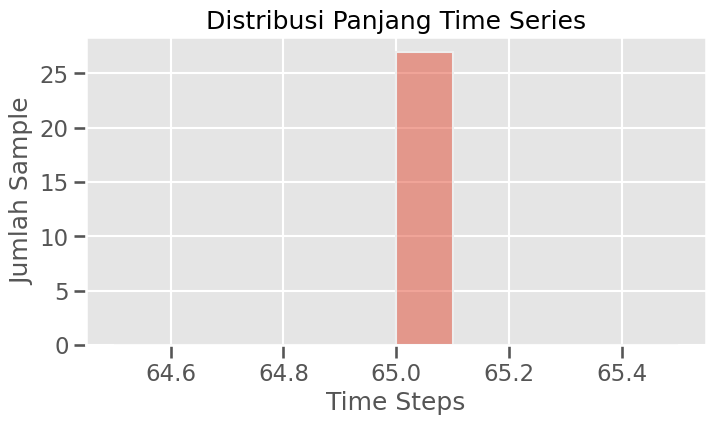

In [6]:
time_steps = [len(sample) for sample in X_train]

plt.figure(figsize=(8,4))
sns.histplot(time_steps, bins=10, kde=True)
plt.title("Distribusi Panjang Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Jumlah Sample")
plt.show()


### Distribusi Label

In [7]:
import numpy as np
import pandas as pd

print("=== DISTRIBUSI LABEL TRAIN ===")
print(pd.Series(y_train).value_counts())

print("\n=== DISTRIBUSI LABEL TEST ===")
print(pd.Series(y_test).value_counts())


=== DISTRIBUSI LABEL TRAIN ===
2    16
1    11
Name: count, dtype: int64

=== DISTRIBUSI LABEL TEST ===
2    588
1    365
Name: count, dtype: int64


### Jumlah kelas sample Train

In [ ]:
print("Jumlah kelas:", len(np.unique(y_train)))

Jumlah kelas: 2


### Jumlah Label Unik Sample Train

In [9]:
print("Label unik  :", np.unique(y_train))

Label unik  : ['1' '2']


### Distribusi label pada data Train

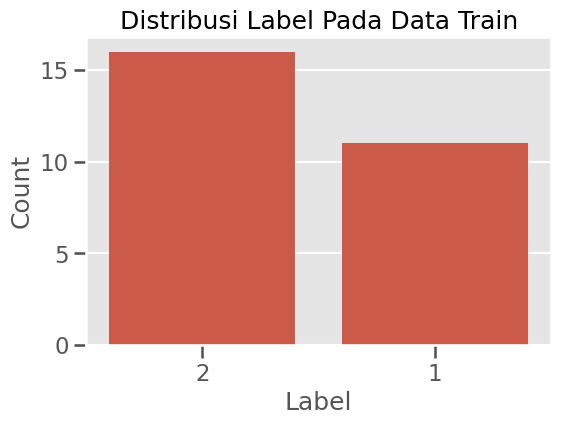

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Distribusi Label Pada Data Train")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Lihat Sampel Data (nilai sensor & label)

In [12]:
print("=== SAMPLE DATA ===")
print("---5 sample pertama X_train---")
print(X_train[:5])
print()
print("---5 label pertama Y_train---")
print(y_train[:5])

=== SAMPLE DATA ===
---5 sample pertama X_train---
[[-0.77065276 -1.2791193  -0.26208652  1.5177601   2.2805596   1.0092365
  -0.51634828 -1.5334238  -0.77065276  1.0092365   2.5348213   2.7890831
   1.7720218  -0.26208652 -1.5334238  -2.0418904  -1.5334238  -0.51634828
  -0.26208652 -0.26208652 -0.51634828 -0.51634828 -0.26208652 -0.26208652
  -0.26208652 -0.00782475  0.24645125  0.24645125  0.24645125  0.24645125
  -0.00782475 -0.26208652 -0.51634828 -0.26208652 -0.00782475  0.24645125
   0.24645125 -0.00782475 -0.26208652 -0.00782475 -0.00782475 -0.26208652
  -0.77065276 -0.77065276 -0.26208652 -0.26208652 -0.77065276  0.50071301
   1.2634983   2.2805596   2.2805596   1.2634983   0.24645125 -0.51634828
  -1.2791193  -1.2791193  -0.77065276 -0.26208652 -0.00782475 -0.00782475
  -0.51634828 -0.26208652 -0.00782475 -0.00782475  0.50071301]
 [-0.69145906  0.03736889  0.28031154  0.28031154  0.52324058  0.52324058
   0.52324058  0.52324058  0.28031154 -0.69145906 -0.44848921  0.76616963


### Statistik Global (mean, min, max, std)

In [13]:
import numpy as np

print("=== STATISTIK GLOBAL TRAIN ===")
print("Mean :", np.mean(X_train))
print("Std  :", np.std(X_train))
print("Min  :", np.min(X_train))
print("Max  :", np.max(X_train))

print("\n=== STATISTIK GLOBAL TEST ===")
print("Mean :", np.mean(X_test))
print("Std  :", np.std(X_test))
print("Min  :", np.min(X_test))
print("Max  :", np.max(X_test))


=== STATISTIK GLOBAL TRAIN ===
Mean : -2.0569799665417967e-10
Std  : 0.9922778774049984
Min  : -4.137978
Max  : 4.2306925

=== STATISTIK GLOBAL TEST ===
Mean : 1.8966336125783224e-11
Std  : 0.9922778766509018
Min  : -4.0211879
Max  : 4.5016686


### Cek Missing Value pada TRAIN & TEST

In [14]:
import numpy as np

print("=== MISSING VALUE CHECK ===")

print("Missing value di X_train:", np.isnan(X_train).sum())
print("Missing value di X_test :", np.isnan(X_test).sum())

missing_y_train = sum([1 for v in y_train if v is None or v == "" or str(v).lower()=="nan"])
missing_y_test  = sum([1 for v in y_test if v is None or v == "" or str(v).lower()=="nan"])

print("Missing value di y_train:", missing_y_train)
print("Missing value di y_test :", missing_y_test)

=== MISSING VALUE CHECK ===
Missing value di X_train: 0
Missing value di X_test : 0
Missing value di y_train: 0
Missing value di y_test : 0


### Visualisasi Missing Value (Heatmap)

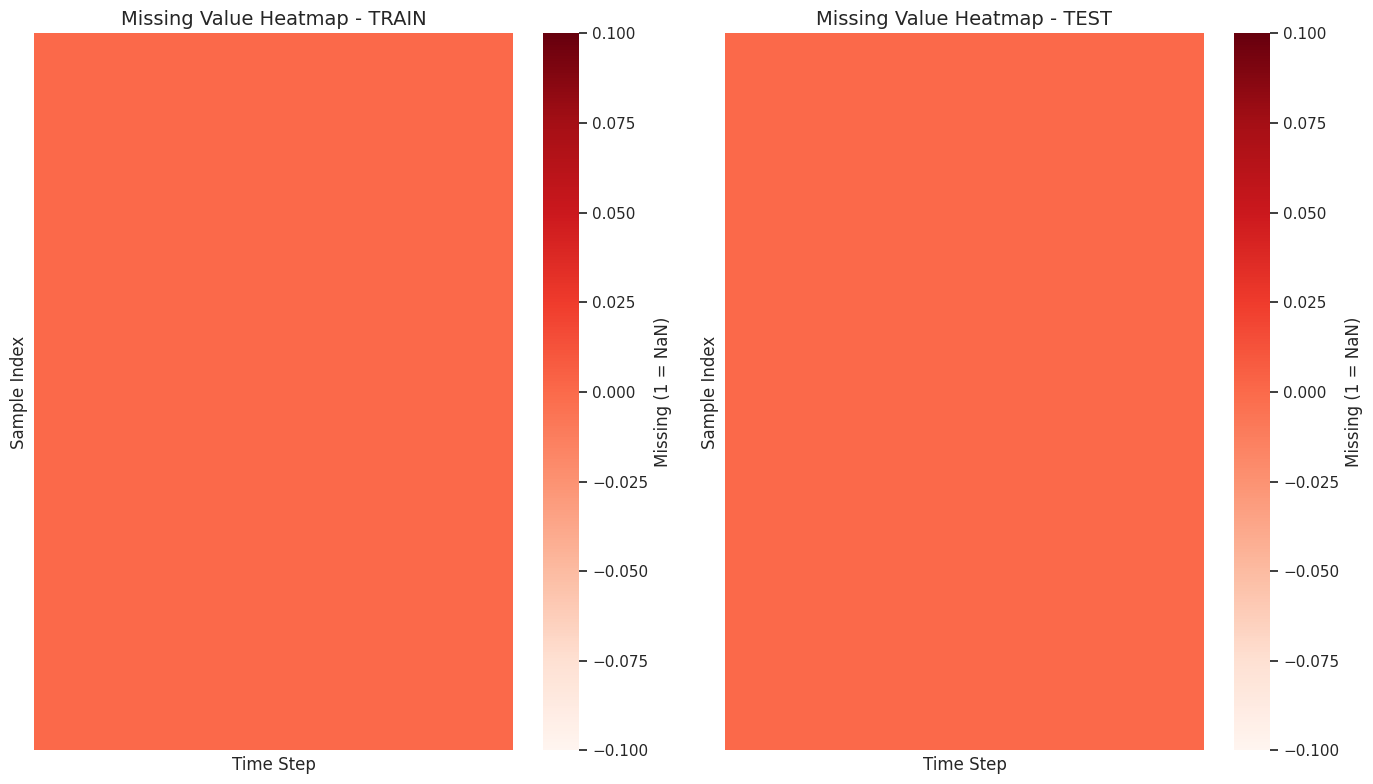

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")  # biar clean

# ==== HEATMAP TRAIN & TEST DALAM SATU FIGURE ====
plt.figure(figsize=(14, 8))

# --- TRAIN ---
plt.subplot(1, 2, 1)
sns.heatmap(
    np.isnan(X_train),
    cmap="Reds",
    cbar=True,
    cbar_kws={"label": "Missing (1 = NaN)"},
    xticklabels=False,
    yticklabels=False
)
plt.title("Missing Value Heatmap - TRAIN", fontsize=14)
plt.xlabel("Time Step")
plt.ylabel("Sample Index")

# --- TEST ---
plt.subplot(1, 2, 2)
sns.heatmap(
    np.isnan(X_test),
    cmap="Reds",
    cbar=True,
    cbar_kws={"label": "Missing (1 = NaN)"},
    xticklabels=False,
    yticklabels=False
)
plt.title("Missing Value Heatmap - TEST", fontsize=14)
plt.xlabel("Time Step")
plt.ylabel("Sample Index")

plt.tight_layout()
plt.show()


### Distribusi Nilai Sensor 

Melihat apakah nilai sensornya normal, condong, atau ada outlier.

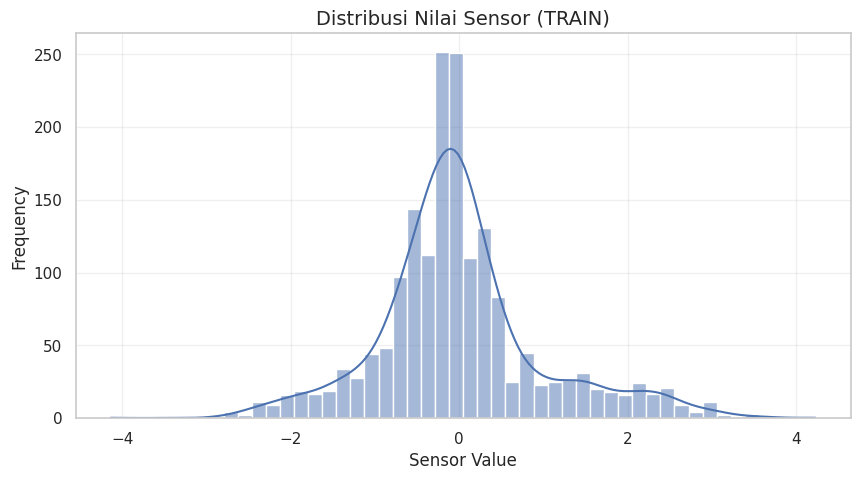

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 5))
sns.histplot(X_train.flatten(), bins=50, kde=True)
plt.title("Distribusi Nilai Sensor (TRAIN)", fontsize=14)
plt.xlabel("Sensor Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


### Boxplot (Deteksi Outlier)



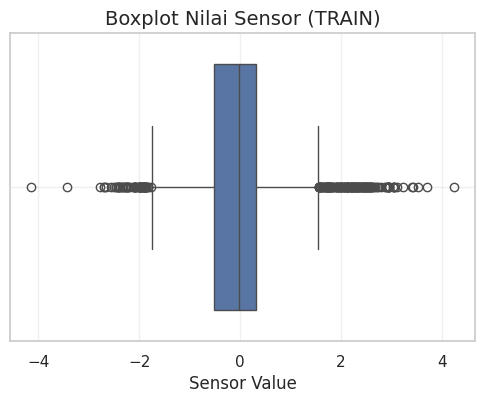

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=X_train.flatten())
plt.title("Boxplot Nilai Sensor (TRAIN)", fontsize=14)
plt.xlabel("Sensor Value")
plt.grid(alpha=0.3)
plt.show()


### Deteksi Outlier Global Menggunakan IQR

Jumlah outlier global: 211


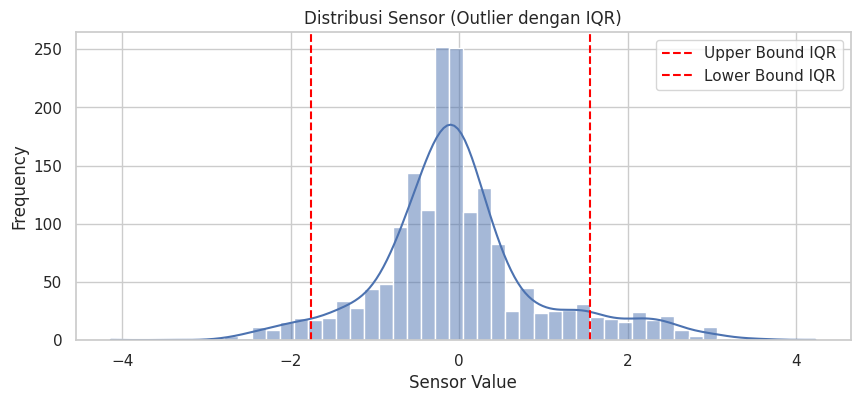

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# flatten data untuk outlier global
data_flat = X_train.flatten()

Q1 = np.percentile(data_flat, 25)
Q3 = np.percentile(data_flat, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (data_flat < lower_bound) | (data_flat > upper_bound)
print("Jumlah outlier global:", np.sum(outliers))

plt.figure(figsize=(10,4))
sns.histplot(data_flat, bins=50, kde=True)
plt.axvline(upper_bound, color="red", linestyle="--", label="Upper Bound IQR")
plt.axvline(lower_bound, color="red", linestyle="--", label="Lower Bound IQR")
plt.title("Distribusi Sensor (Outlier dengan IQR)")
plt.xlabel("Sensor Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Visualisasi Outlier pada Time Series (Per Sample)

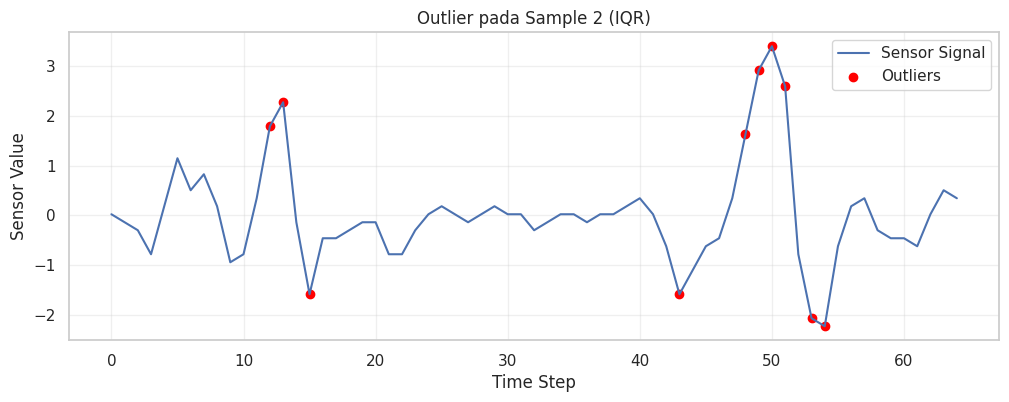

Jumlah outlier pada sample: 10


In [19]:
sample_idx = 2  # pilih sample
sample = X_train[sample_idx]

Q1 = np.percentile(sample, 25)
Q3 = np.percentile(sample, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sample_out_idx = np.where((sample < lower_bound) | (sample > upper_bound))[0]

plt.figure(figsize=(12,4))
plt.plot(sample, label="Sensor Signal")
plt.scatter(sample_out_idx, sample[sample_out_idx], color="red", label="Outliers")
plt.title(f"Outlier pada Sample {sample_idx} (IQR)")
plt.xlabel("Time Step")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Jumlah outlier pada sample:", len(sample_out_idx))


### Deteksi “Flat Signal” Tetap Sama

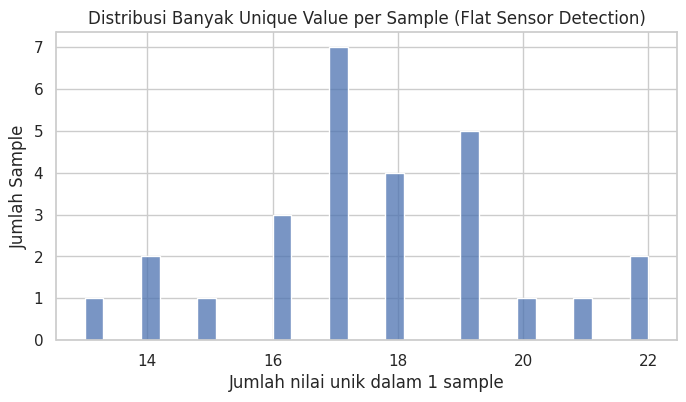

Sample yang terindikasi sensor flat: []


In [20]:
flat_counts = []

for i in range(len(X_train)):
    unique_vals = np.unique(X_train[i])
    flat_counts.append(len(unique_vals))

plt.figure(figsize=(8,4))
sns.histplot(flat_counts, bins=30)
plt.title("Distribusi Banyak Unique Value per Sample (Flat Sensor Detection)")
plt.xlabel("Jumlah nilai unik dalam 1 sample")
plt.ylabel("Jumlah Sample")
plt.show()

flat_samples = np.where(np.array(flat_counts) < 5)[0]
print("Sample yang terindikasi sensor flat:", flat_samples)


### Analisis Hubungan Antar Sensor dengan Heatmap dan Pairplot

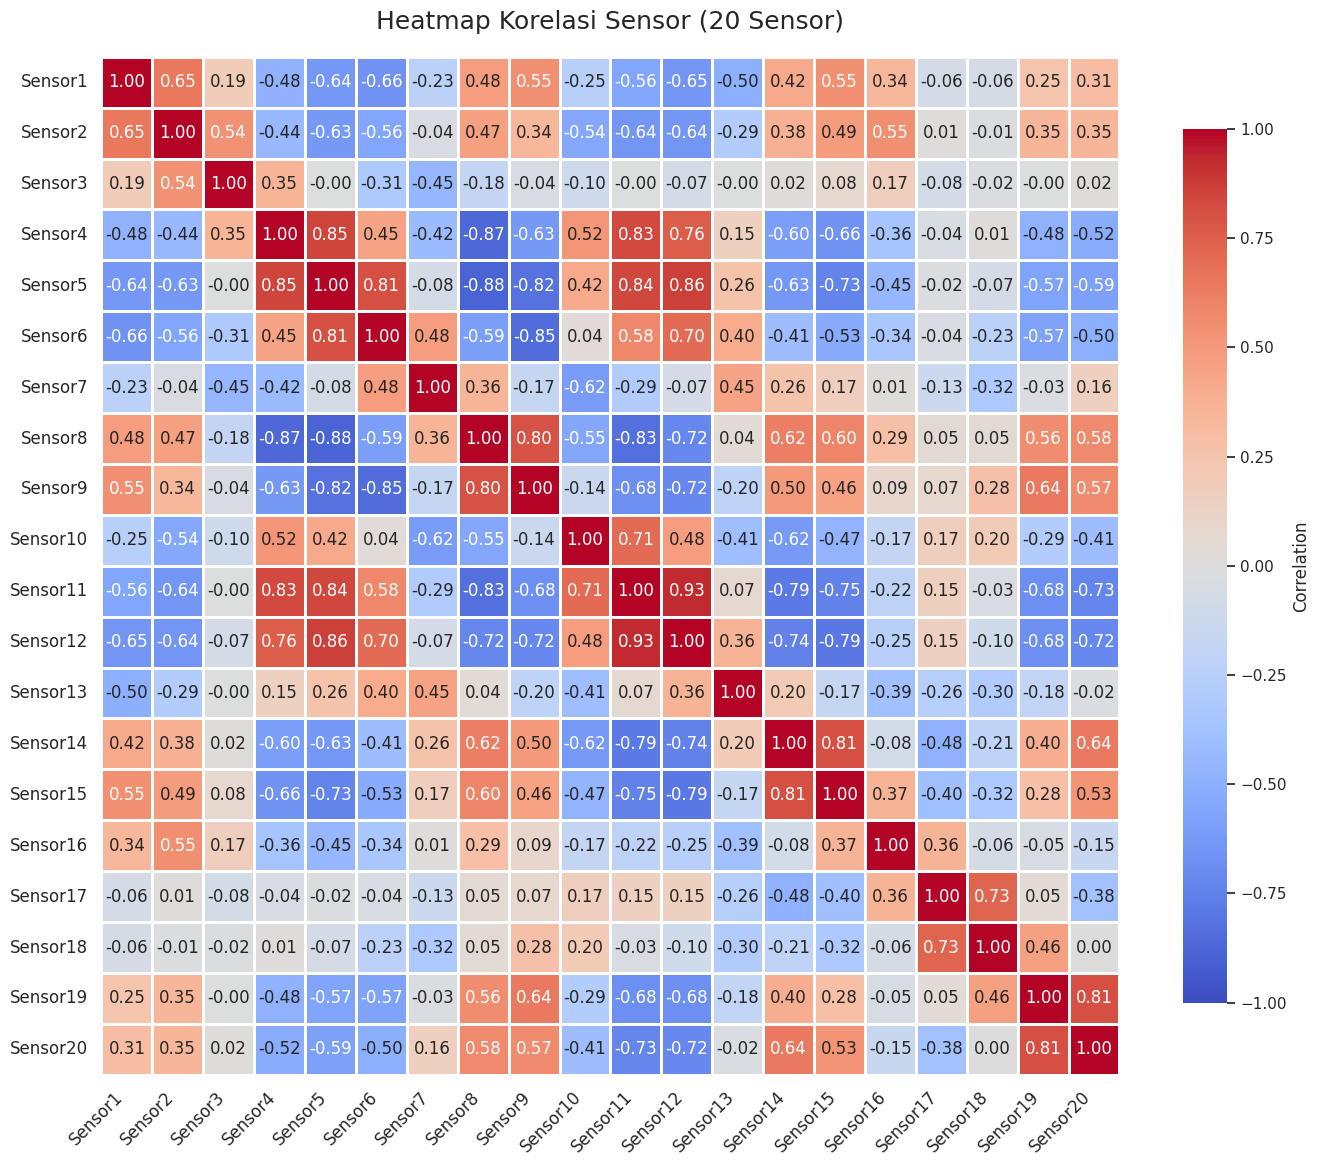

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ Konversi X_train ke DataFrame
# ===============================
n_sensors = X_train.shape[1]  # jumlah sensor
sensor_names = [f"Sensor{i+1}" for i in range(n_sensors)]
df_sensors = pd.DataFrame(X_train, columns=sensor_names)

# ===============================
# 2️⃣ Korelasi antar sensor
# ===============================
corr_matrix = df_sensors.corr()

# ===============================
# 3️⃣ Heatmap Korelasi 
# ===============================
# jika sensor terlalu banyak, pilih subset
max_sensors_for_heatmap = 20
if n_sensors > max_sensors_for_heatmap:
    subset_sensors = df_sensors.columns[:max_sensors_for_heatmap]
    corr_matrix_subset = df_sensors[subset_sensors].corr()
else:
    subset_sensors = df_sensors.columns
    corr_matrix_subset = corr_matrix

# Buat figure lebih besar
plt.figure(figsize=(14,12))

# Heatmap
sns.heatmap(
    corr_matrix_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={"shrink":0.8, "label":"Correlation"},
    square=True   # membuat kotak sel simetris
)

# Atur ticks supaya tidak tumpang tindih
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Tambahkan judul
plt.title(f"Heatmap Korelasi Sensor ({len(subset_sensors)} Sensor)", fontsize=18, pad=20)

plt.tight_layout()
plt.show()


### Visualisasi Sinyal Sensor dari Waktu ke Waktu

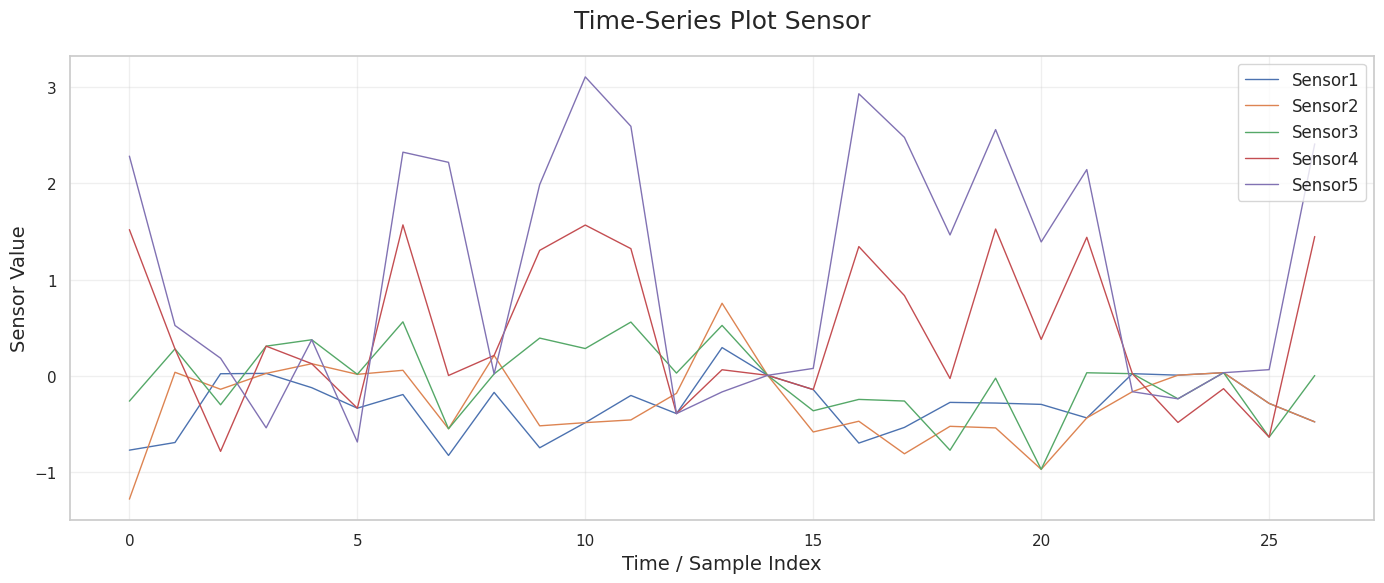

In [22]:
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ Tentukan sensor yang akan diplot
# ===============================
max_sensors_for_plot = 5  # jumlah sensor yang akan diplot supaya tidak terlalu ramai
if n_sensors > max_sensors_for_plot:
    sensors_to_plot = df_sensors.columns[:max_sensors_for_plot]
else:
    sensors_to_plot = df_sensors.columns

# ===============================
# 2️⃣ Buat figure time-series
# ===============================
plt.figure(figsize=(14, 6))

for sensor in sensors_to_plot:
    plt.plot(df_sensors[sensor], label=sensor, linewidth=1)

plt.title("Time-Series Plot Sensor", fontsize=18, pad=20)
plt.xlabel("Time / Sample Index", fontsize=14)
plt.ylabel("Sensor Value", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Time-Series Overlay per Kelas

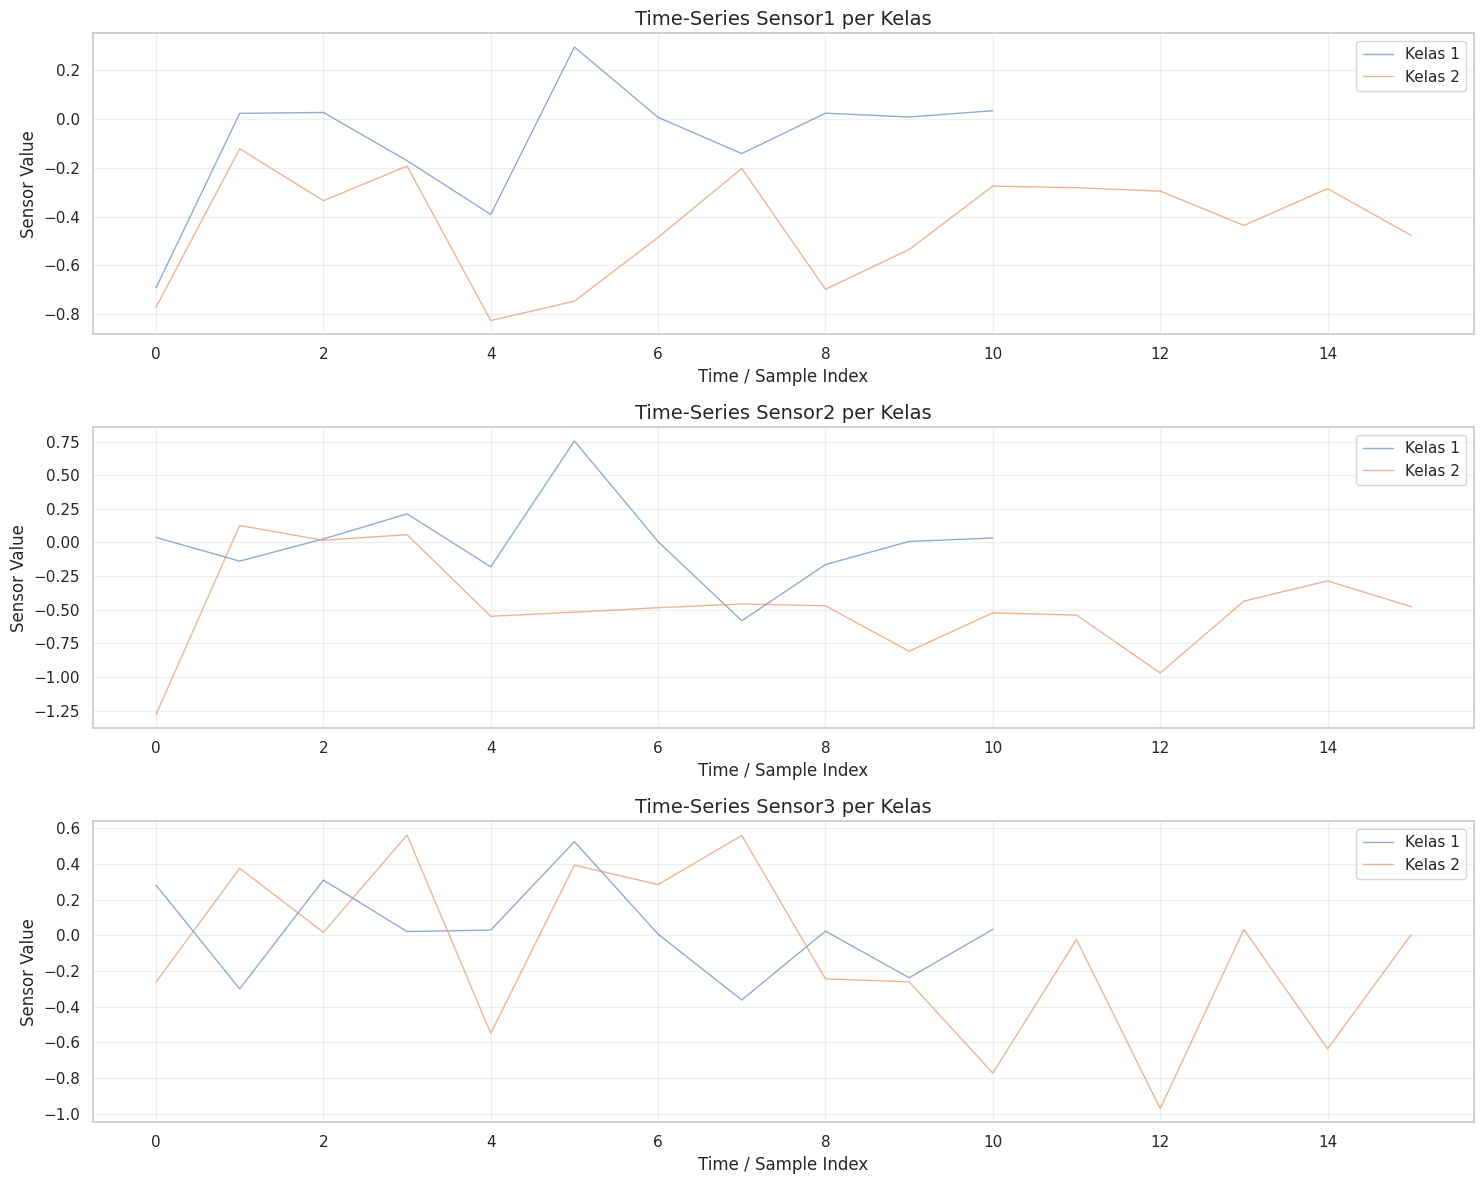

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ===============================
# Pastikan X_train dan y_train sudah ada
# ===============================
# Konversi ke DataFrame agar mudah diakses
n_sensors = X_train.shape[1]
df_sensors = pd.DataFrame(X_train, columns=[f"Sensor{i+1}" for i in range(n_sensors)])
df_sensors['Label'] = y_train  # tambahkan label

# ===============================
# Pilih sensor untuk plot (jangan terlalu banyak)
# ===============================
max_sensors_for_plot = 3
if n_sensors > max_sensors_for_plot:
    sensors_to_plot = df_sensors.columns[:max_sensors_for_plot]
else:
    sensors_to_plot = df_sensors.columns[:-1]  # exclude 'Label'

# ===============================
# Plot time-series overlay per kelas
# ===============================
plt.figure(figsize=(15, 4 * len(sensors_to_plot)))

for i, sensor in enumerate(sensors_to_plot, 1):
    plt.subplot(len(sensors_to_plot), 1, i)
    
    for label in np.unique(y_train):
        # ambil subset data untuk kelas tertentu
        class_data = df_sensors[df_sensors['Label'] == label][sensor]
        plt.plot(class_data.values, label=f'Kelas {label}', alpha=0.6, linewidth=1)
    
    plt.title(f"Time-Series {sensor} per Kelas", fontsize=14)
    plt.xlabel("Time / Sample Index", fontsize=12)
    plt.ylabel("Sensor Value", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Clustermap Statistik Fitur Sensor per Kelas

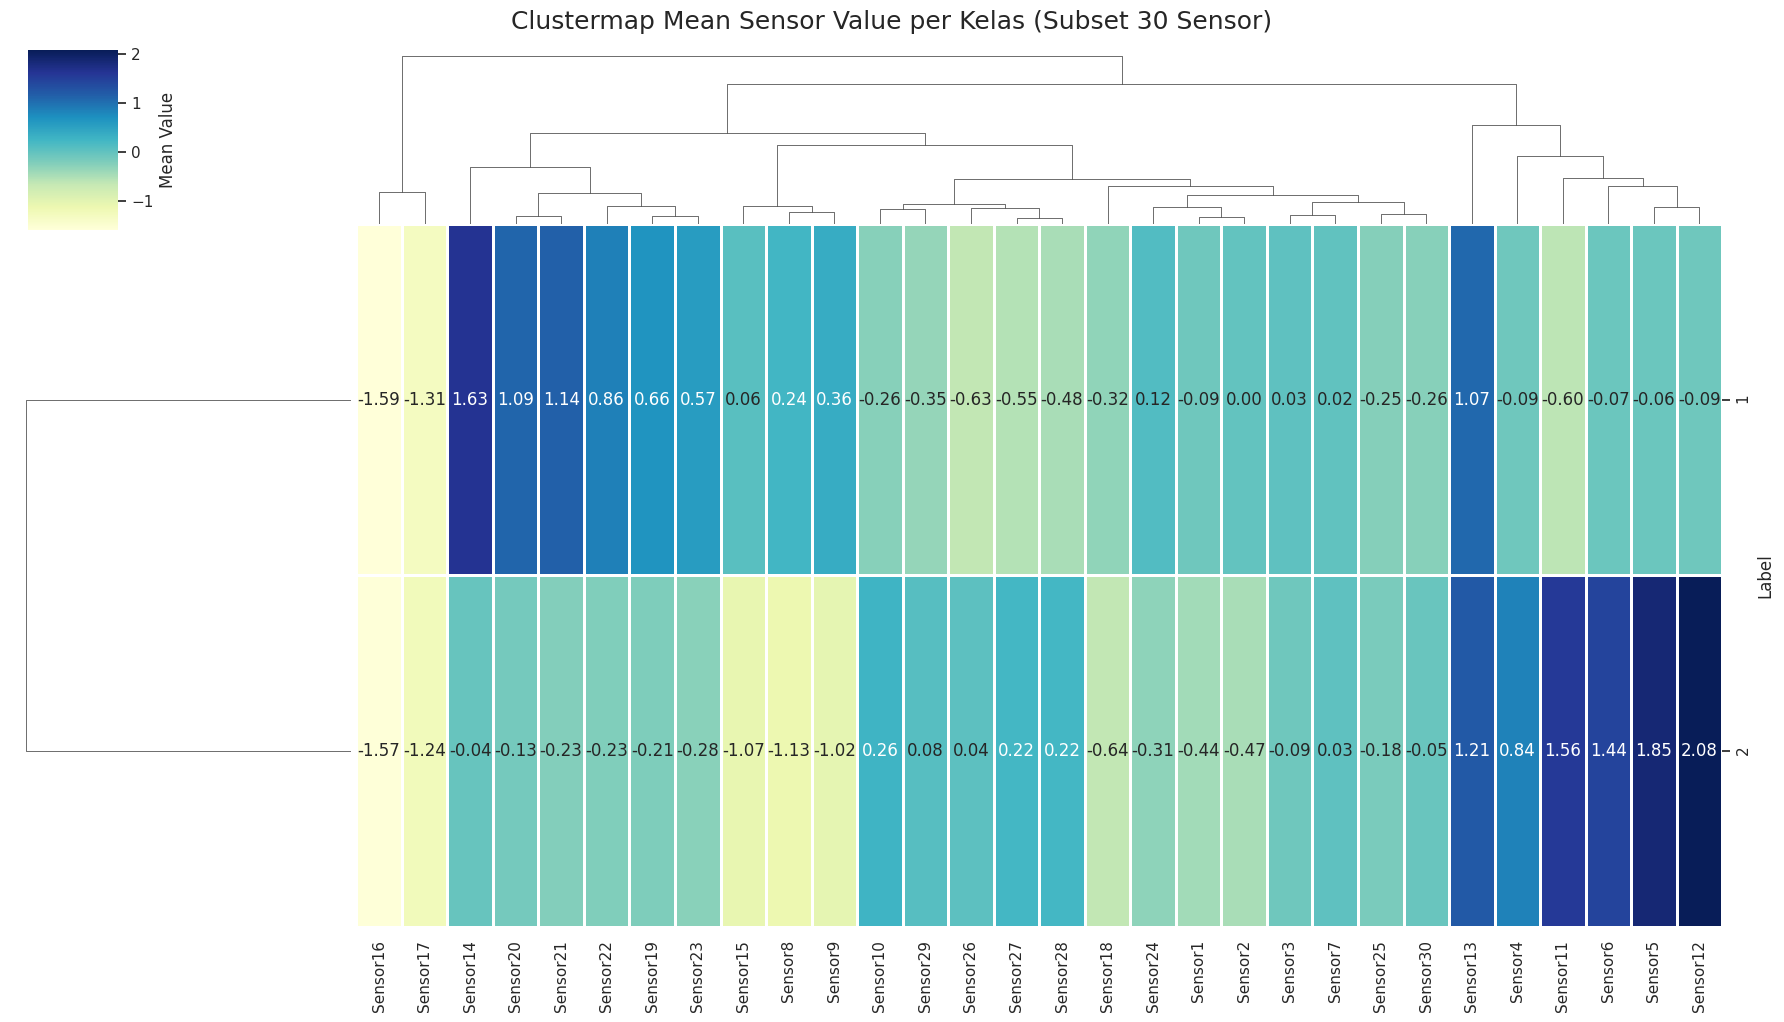

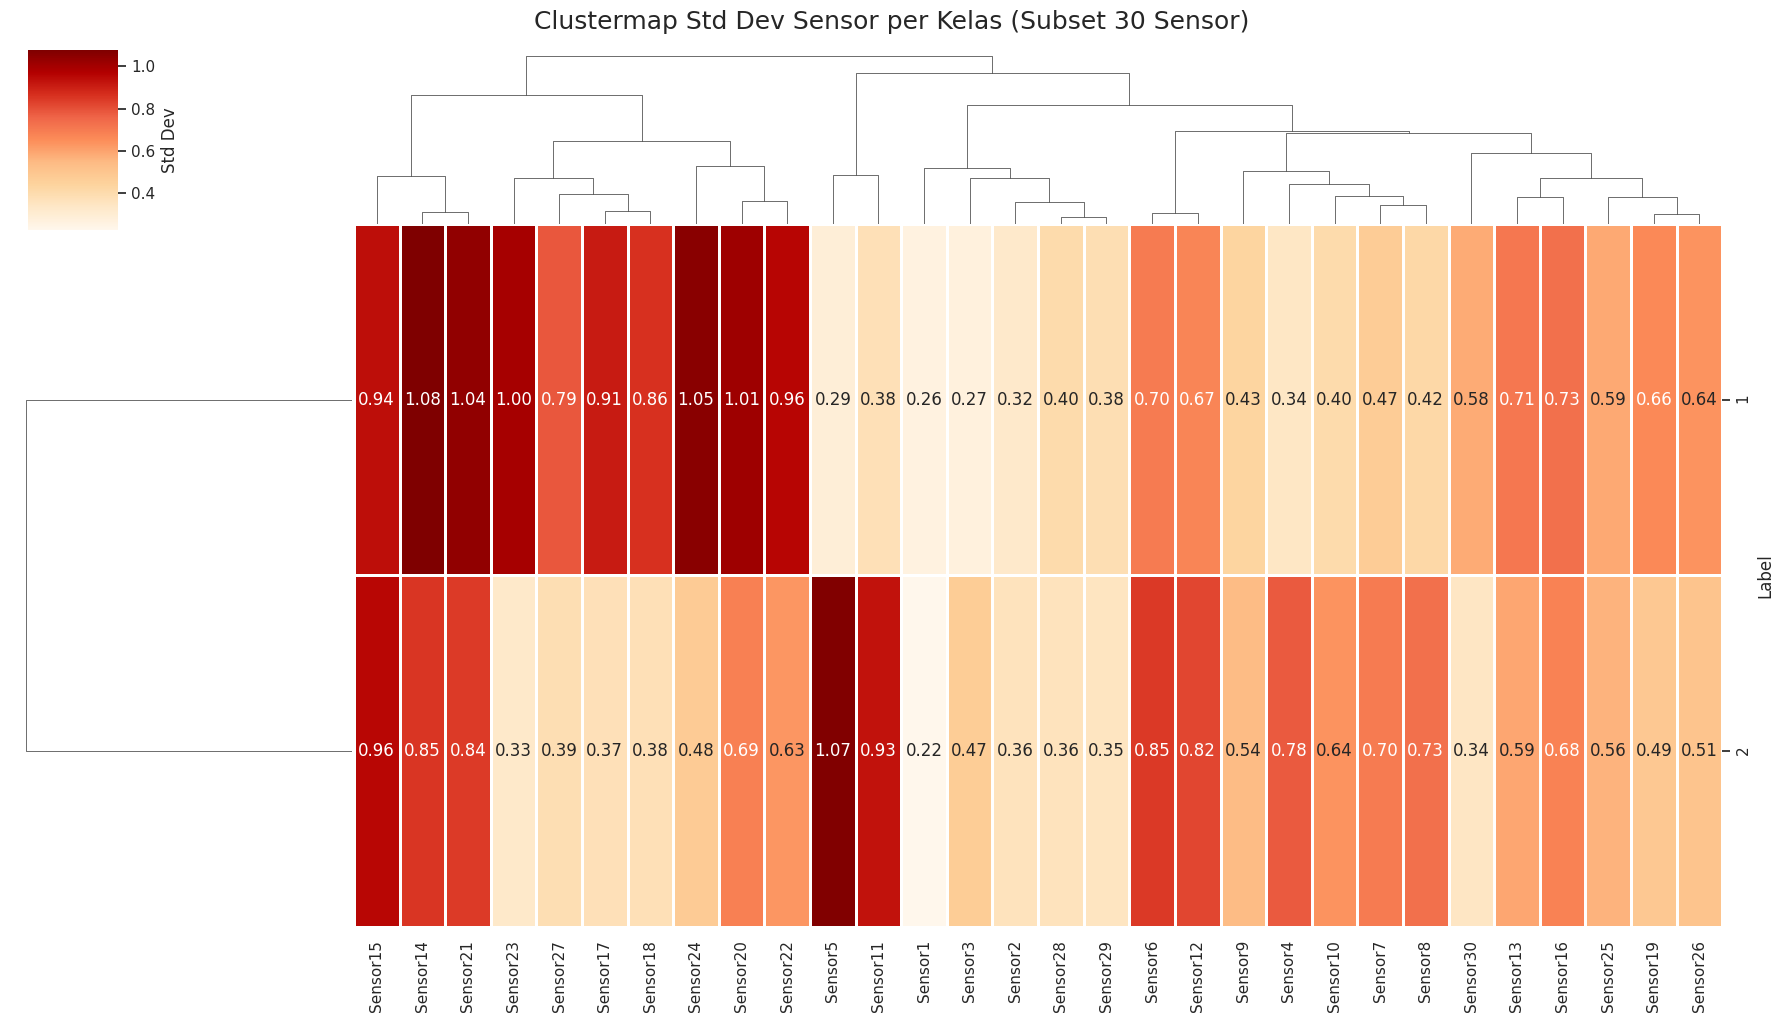

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ Konversi X_train ke DataFrame dan tambahkan label
# ===============================
n_sensors = X_train.shape[1]
df_sensors = pd.DataFrame(X_train, columns=[f"Sensor{i+1}" for i in range(n_sensors)])
df_sensors['Label'] = y_train  # tambahkan label kelas

# ===============================
# 2️⃣ Hitung mean per sensor per kelas
# ===============================
mean_stats = df_sensors.groupby('Label').mean()

# ===============================
# 3️⃣ Heatmap rapi menggunakan clustermap
# ===============================
# Pilih subset sensor jika terlalu banyak (misal 30 sensor pertama)
max_sensors = 30
subset_sensors = mean_stats.columns[:max_sensors]

sns.set_theme(style="white")  # tema bersih
clustermap = sns.clustermap(
    mean_stats[subset_sensors], 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=0.8, 
    figsize=(18,10),
    cbar_kws={"label": "Mean Value"},
    row_cluster=True,  # cluster baris (kelas)
    col_cluster=True   # cluster kolom (sensor)
)

clustermap.fig.suptitle("Clustermap Mean Sensor Value per Kelas (Subset 30 Sensor)", fontsize=18, y=1.02)
plt.show()

# ===============================
# 4️⃣ Opsional: Heatmap standar deviasi per kelas
# ===============================
std_stats = df_sensors.groupby('Label').std()

subset_sensors_std = std_stats.columns[:max_sensors]

sns.set_theme(style="white")
clustermap_std = sns.clustermap(
    std_stats[subset_sensors_std],
    annot=True,
    fmt=".2f",
    cmap="OrRd",
    linewidths=0.8,
    figsize=(18,10),
    cbar_kws={"label": "Std Dev"},
    row_cluster=True,
    col_cluster=True
)
clustermap_std.fig.suptitle("Clustermap Std Dev Sensor per Kelas (Subset 30 Sensor)", fontsize=18, y=1.02)
plt.show()


### Visualisasi Cluster Kelas Menggunakan PCA dan t-SNE

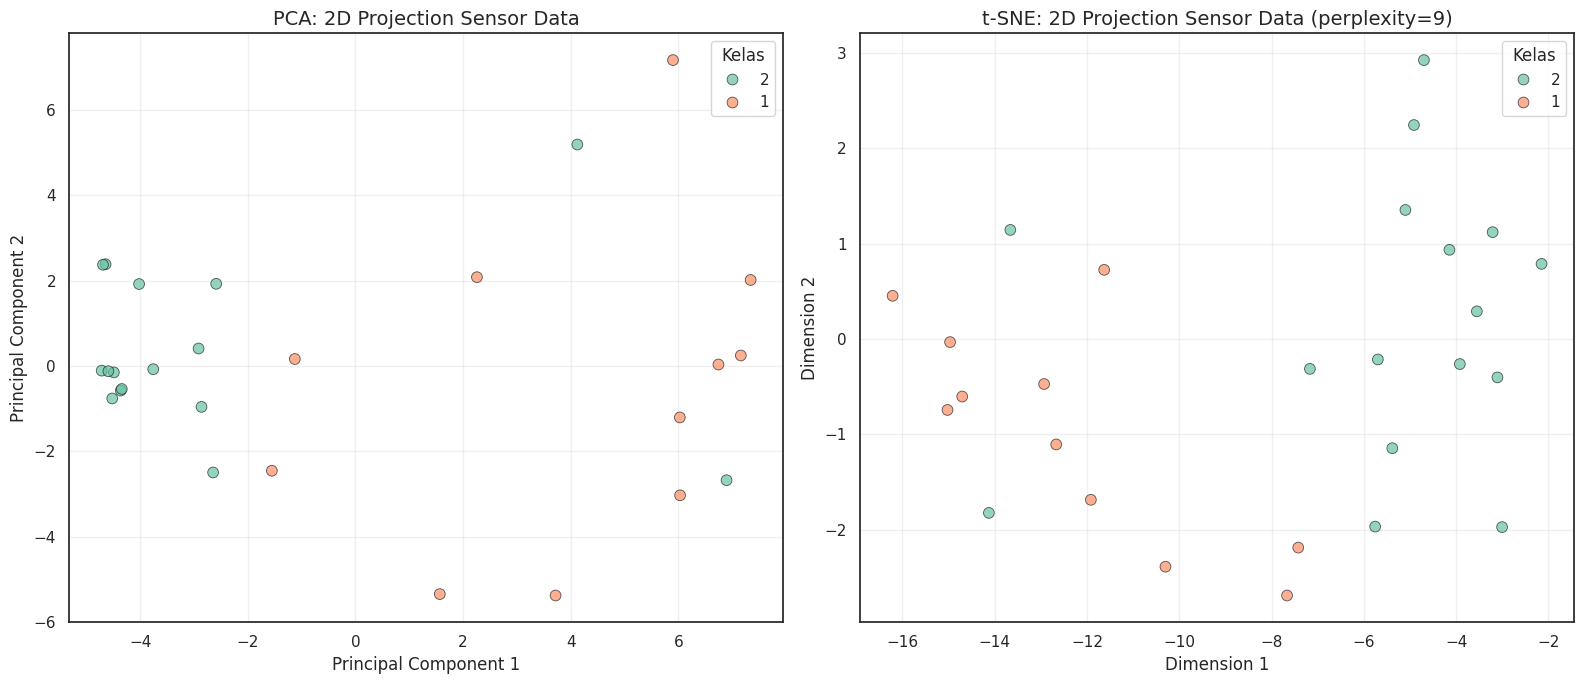

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ===============================
# 1️⃣ Konversi X_train ke DataFrame (opsional)
# ===============================
df_sensors = pd.DataFrame(X_train, columns=[f"Sensor{i+1}" for i in range(X_train.shape[1])])

# ===============================
# 2️⃣ Standarisasi data
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sensors)

# ===============================
# 3️⃣ PCA (2 komponen) untuk visualisasi
# ===============================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Label'] = y_train

# ===============================
# 4️⃣ t-SNE (2D) untuk visualisasi cluster
# ===============================
# Perplexity disesuaikan: harus < n_samples
n_samples = X_scaled.shape[0]
perplexity = min(30, max(5, n_samples // 3))  # aman untuk dataset kecil

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
df_tsne['Label'] = y_train

# ===============================
# 5️⃣ Plot PCA dan t-SNE berdampingan
# ===============================
plt.figure(figsize=(16,7))

# PCA subplot
plt.subplot(1,2,1)
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Label',
    palette='Set2',
    data=df_pca,
    s=60, alpha=0.7, edgecolor='k'
)
plt.title("PCA: 2D Projection Sensor Data", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Kelas")
plt.grid(alpha=0.3)

# t-SNE subplot
plt.subplot(1,2,2)
sns.scatterplot(
    x='Dim1', y='Dim2',
    hue='Label',
    palette='Set2',
    data=df_tsne,
    s=60, alpha=0.7, edgecolor='k'
)
plt.title(f"t-SNE: 2D Projection Sensor Data (perplexity={perplexity})", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Kelas")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Train vs Test: Memeriksa Konsistensi Data Sensor

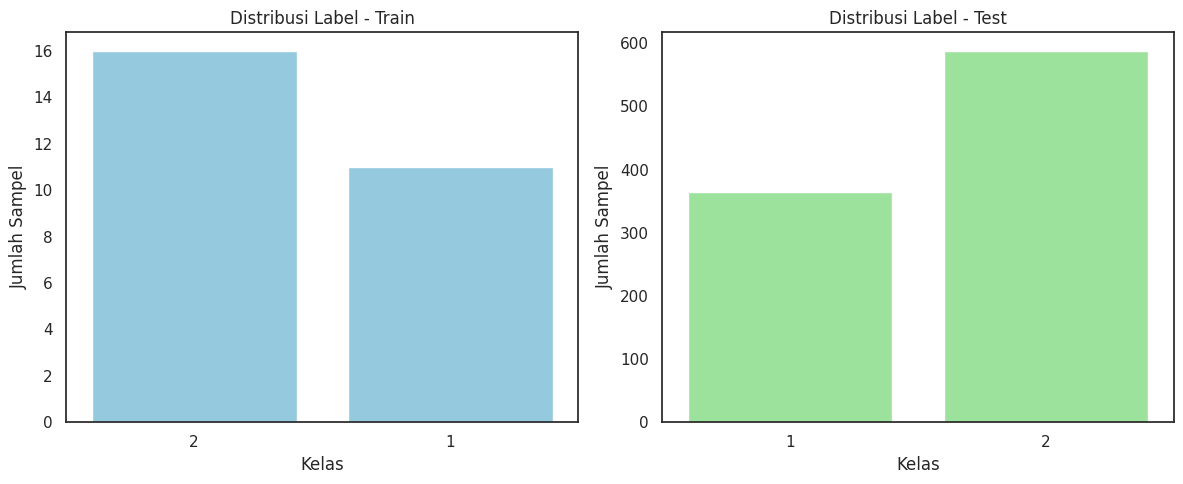

Statistik Sensor - Train:
            mean    std    min    max
Sensor1  -0.294  0.292 -0.825  0.294
Sensor2  -0.281  0.414 -1.279  0.754
Sensor3  -0.043  0.398 -0.970  0.561
Sensor4   0.457  0.783 -0.783  1.567
Sensor5   1.073  1.270 -0.686  3.103
...         ...    ...    ...    ...
Sensor61  0.323  1.052 -0.934  2.514
Sensor62 -0.240  0.748 -2.387  1.363
Sensor63 -0.680  1.130 -4.138  0.523
Sensor64 -0.367  0.988 -2.410  0.719
Sensor65  0.041  0.733 -1.897  0.984

[65 rows x 4 columns]

Statistik Sensor - Test:
            mean    std    min    max
Sensor1  -0.192  0.396 -1.540  1.955
Sensor2  -0.257  0.501 -1.838  2.396
Sensor3  -0.118  0.500 -2.683  2.680
Sensor4   0.362  0.743 -1.697  2.150
Sensor5   0.905  1.211 -2.010  3.464
...         ...    ...    ...    ...
Sensor61  0.315  0.940 -1.872  3.707
Sensor62 -0.107  0.950 -3.244  3.845
Sensor63 -0.395  0.973 -3.842  3.610
Sensor64 -0.275  0.783 -2.779  2.136
Sensor65  0.061  0.689 -2.790  2.878

[65 rows x 4 columns]


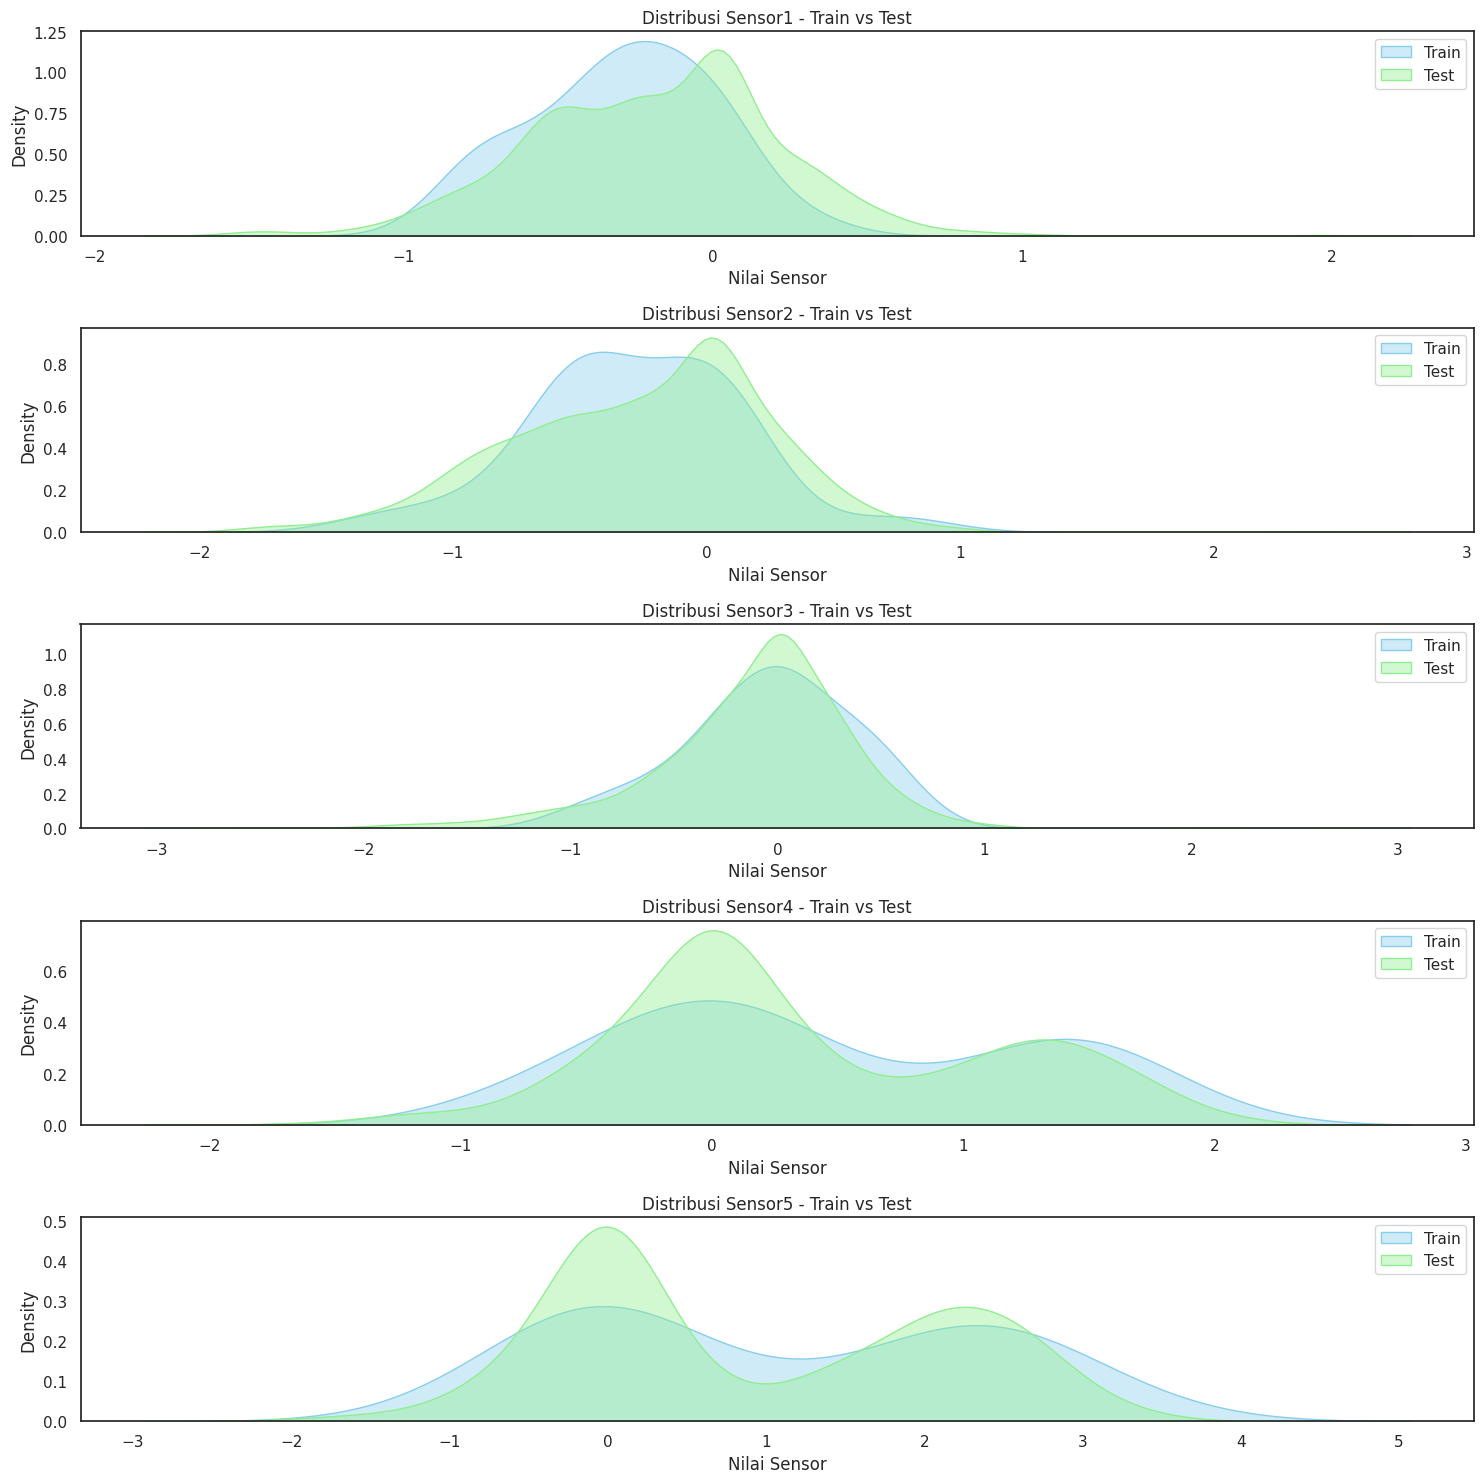

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ Konversi ke DataFrame dan tambahkan label
# ===============================
n_sensors = X_train.shape[1]

df_train = pd.DataFrame(X_train, columns=[f"Sensor{i+1}" for i in range(n_sensors)])
df_train['Label'] = y_train

df_test = pd.DataFrame(X_test, columns=[f"Sensor{i+1}" for i in range(n_sensors)])
df_test['Label'] = y_test

# ===============================
# 2️⃣ Distribusi label kelas (bebas warning)
# ===============================
plt.figure(figsize=(12,5))

# Train
plt.subplot(1,2,1)
sns.countplot(x='Label', data=df_train, color='skyblue')  # satu warna
plt.title("Distribusi Label - Train")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")

# Test
plt.subplot(1,2,2)
sns.countplot(x='Label', data=df_test, color='lightgreen')  # satu warna
plt.title("Distribusi Label - Test")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")

plt.tight_layout()
plt.show()

# ===============================
# 3️⃣ Statistik ringkas tiap sensor
# ===============================
stats_train = df_train.describe().T[['mean','std','min','max']]
stats_test = df_test.describe().T[['mean','std','min','max']]

print("Statistik Sensor - Train:\n", stats_train.round(3))
print("\nStatistik Sensor - Test:\n", stats_test.round(3))

# ===============================
# 4️⃣ KDE / Histogram per sensor untuk membandingkan train vs test
# ===============================
max_sensors_for_plot = 5
if n_sensors > max_sensors_for_plot:
    sensors_to_plot = df_train.columns[:max_sensors_for_plot]
else:
    sensors_to_plot = df_train.columns[:-1]  # exclude 'Label'

plt.figure(figsize=(15, 3*len(sensors_to_plot)))
for i, sensor in enumerate(sensors_to_plot, 1):
    plt.subplot(len(sensors_to_plot),1,i)
    sns.kdeplot(df_train[sensor], label='Train', fill=True, alpha=0.4, color='skyblue')
    sns.kdeplot(df_test[sensor], label='Test', fill=True, alpha=0.4, color='lightgreen')
    plt.title(f"Distribusi {sensor} - Train vs Test")
    plt.xlabel("Nilai Sensor")
    plt.ylabel("Density")
    plt.legend()
plt.tight_layout()
plt.show()


## Prepocessing

### Variabel Raw

In [26]:
# ==========================
# Copy Variabel Raw
# ==========================
X_train_raw = X_train.copy()
y_train_raw = y_train_num.copy()
X_test_raw = X_test.copy()
y_test_raw = y_test_num.copy()

# ==========================
# Print informasi
# ==========================
print("=== X_train_raw ===")
print("Shape:", X_train_raw.shape)
print("5 baris pertama:\n", X_train_raw[:5])

print("\n=== y_train_raw ===")
print("Shape:", y_train_raw.shape)
print("5 label pertama:", y_train_raw[:5])

print("\n=== X_test_raw ===")
print("Shape:", X_test_raw.shape)
print("5 baris pertama:\n", X_test_raw[:5])

print("\n=== y_test_raw ===")
print("Shape:", y_test_raw.shape)
print("5 label pertama:", y_test_raw[:5])


=== X_train_raw ===
Shape: (27, 65)
5 baris pertama:
 [[-0.77065276 -1.2791193  -0.26208652  1.5177601   2.2805596   1.0092365
  -0.51634828 -1.5334238  -0.77065276  1.0092365   2.5348213   2.7890831
   1.7720218  -0.26208652 -1.5334238  -2.0418904  -1.5334238  -0.51634828
  -0.26208652 -0.26208652 -0.51634828 -0.51634828 -0.26208652 -0.26208652
  -0.26208652 -0.00782475  0.24645125  0.24645125  0.24645125  0.24645125
  -0.00782475 -0.26208652 -0.51634828 -0.26208652 -0.00782475  0.24645125
   0.24645125 -0.00782475 -0.26208652 -0.00782475 -0.00782475 -0.26208652
  -0.77065276 -0.77065276 -0.26208652 -0.26208652 -0.77065276  0.50071301
   1.2634983   2.2805596   2.2805596   1.2634983   0.24645125 -0.51634828
  -1.2791193  -1.2791193  -0.77065276 -0.26208652 -0.00782475 -0.00782475
  -0.51634828 -0.26208652 -0.00782475 -0.00782475  0.50071301]
 [-0.69145906  0.03736889  0.28031154  0.28031154  0.52324058  0.52324058
   0.52324058  0.52324058  0.28031154 -0.69145906 -0.44848921  0.766169

### Data untuk data uji streamlit

In [27]:
import pandas as pd

# ==========================
# Ambil semua data test
# ==========================
# Pastikan X_test_all hanya berisi 65 fitur, tanpa kolom label
X_test_all = X_test_raw.copy()  # semua baris fitur
y_test_all = y_test_raw.copy()  # semua label

# ==========================
# Buat DataFrame
# ==========================
# Gunakan hanya 65 fitur
feature_columns = [f"V{i+1}" for i in range(65)]  # pastikan sesuai training
df_test = pd.DataFrame(X_test_all[:, :65], columns=feature_columns)


# ==========================
# Simpan sebagai CSV
# ==========================
df_test.to_csv("streamlit1.csv", index=False)
print("CSV test lengkap siap di-upload ke Streamlit")


CSV test lengkap siap di-upload ke Streamlit


### Noise Filtering / Smoothing Data Sensor

Berikut beberapa opsi yang umum digunakan:

1. Moving Average → rata-rata nilai tetangga. Sederhana dan cepat.

2. Median Filter → bagus untuk menghilangkan spike / outlier singkat.

3. Low-pass Butterworth Filter → lebih canggih, bisa menahan frekuensi tinggi (noise) dan mempertahankan sinyal utama.

Filtering sinyal selesai.
Shape X_train_filtered: (27, 65)
Shape X_test_filtered : (953, 65)


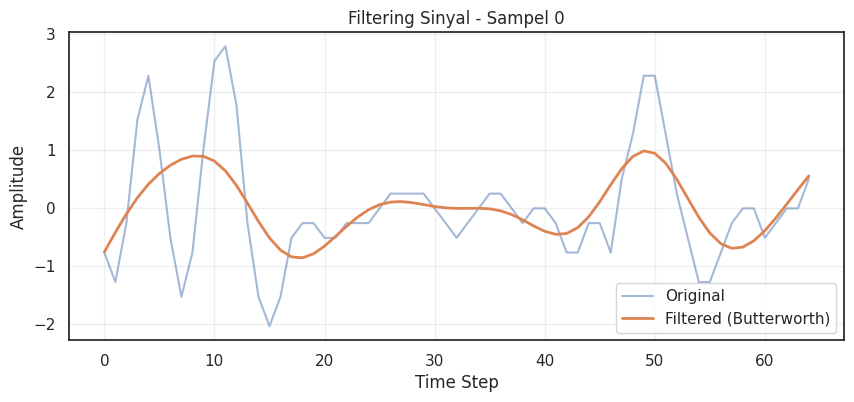

In [87]:
import numpy as np
from scipy.signal import butter, filtfilt, medfilt
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ Definisi fungsi filter
# ===============================

def moving_average(signal, window_size=3):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

def median_filter(signal, kernel_size=3):
    return medfilt(signal, kernel_size=kernel_size)

def butter_lowpass_filter(signal, cutoff=5, fs=65, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# ===============================
# 2️⃣ Terapkan filtering PER BARIS (TIME SERIES)
# ===============================

X_train_filtered = np.zeros_like(X_train_raw)
X_test_filtered  = np.zeros_like(X_test_raw)

for i in range(X_train_raw.shape[0]):
    X_train_filtered[i] = butter_lowpass_filter(
        X_train_raw[i], cutoff=5, fs=65, order=4
    )

for i in range(X_test_raw.shape[0]):
    X_test_filtered[i] = butter_lowpass_filter(
        X_test_raw[i], cutoff=5, fs=65, order=4
    )

print("Filtering sinyal selesai.")
print("Shape X_train_filtered:", X_train_filtered.shape)
print("Shape X_test_filtered :", X_test_filtered.shape)

sample_idx = 0

plt.figure(figsize=(10,4))
plt.plot(X_train_raw[sample_idx], label='Original', alpha=0.5)
plt.plot(X_train_filtered[sample_idx], label='Filtered (Butterworth)', linewidth=2)
plt.title(f'Filtering Sinyal - Sampel {sample_idx}')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Tangani Outlier (Winsorizing)

Outlier telah ditangani dengan Winsorizing.
Train: 319 / 1755 nilai berubah (18.18%)
Test : 11562 / 61945 nilai berubah (18.66%)


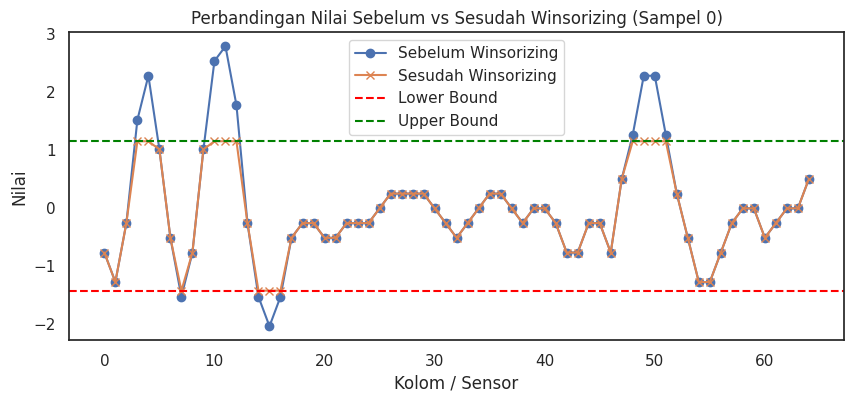

In [88]:
# ============================================================
#Tangani Outlier (Winsorizing)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Misal lower_bound dan upper_bound sudah dihitung sebelumnya
# lower_bound, upper_bound = ... (misal hasil IQR)

# 1️⃣ Salin data dan terapkan Winsorizing
X_train_clean = X_train_raw.copy().clip(lower_bound, upper_bound)
X_test_clean  = X_test_raw.copy().clip(lower_bound, upper_bound)

print("Outlier telah ditangani dengan Winsorizing.")

# ============================================================
# 2️⃣ Hitung jumlah nilai yang berubah
# ============================================================
changes_train = (X_train_clean != X_train_raw)
num_changes_train = np.sum(changes_train)
total_cells_train = X_train_raw.size

changes_test = (X_test_clean != X_test_raw)
num_changes_test = np.sum(changes_test)
total_cells_test = X_test_raw.size

print(f"Train: {num_changes_train} / {total_cells_train} nilai berubah ({num_changes_train/total_cells_train*100:.2f}%)")
print(f"Test : {num_changes_test} / {total_cells_test} nilai berubah ({num_changes_test/total_cells_test*100:.2f}%)")

# ============================================================
# 3️⃣ Plot before-after untuk satu sampel (misal baris pertama)
# ============================================================
sample_idx = 0  # bisa diganti sesuai sampel yang ingin dilihat

plt.figure(figsize=(10,4))
plt.plot(X_train_raw[sample_idx], marker='o', label='Sebelum Winsorizing')
plt.plot(X_train_clean[sample_idx], marker='x', label='Sesudah Winsorizing')
plt.axhline(y=lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axhline(y=upper_bound, color='green', linestyle='--', label='Upper Bound')
plt.title(f'Perbandingan Nilai Sebelum vs Sesudah Winsorizing (Sampel {sample_idx})')
plt.xlabel('Kolom / Sensor')
plt.ylabel('Nilai')
plt.legend()
plt.show()


### Scaling (StandardScaler)

In [89]:
# ============================================================
# Scaling / Standardisasi
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# Anggap X_train_clean dan X_test_clean sudah ada dari Winsorizing

# 1️⃣ Statistik sebelum scaling (opsional, untuk pengecekan)
print("=== Statistik Sebelum Scaling ===")
print("Train set:")
print(pd.DataFrame(X_train_clean).describe().T[['min','25%','50%','mean','75%','max']])
print("\nTest set:")
print(pd.DataFrame(X_test_clean).describe().T[['min','25%','50%','mean','75%','max']])

# 2️⃣ Inisialisasi dan terapkan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled  = scaler.transform(X_test_clean)
print("\nScaling selesai.")

# 3️⃣ Statistik setelah scaling (opsional)
print("\n=== Statistik Setelah Scaling (Train set) ===")
print(pd.DataFrame(X_train_scaled).describe().T[['min','25%','50%','mean','75%','max']])

# 4️⃣ Cek beberapa baris hasil scaling
print("\nContoh 5 baris pertama Train set setelah scaling:")
print(X_train_scaled[:5])

# 5️⃣ Simpan scaler untuk digunakan nanti
joblib.dump(scaler, "scaler_standard.pkl")
print("\nScaler disimpan sebagai 'scaler_standard.pkl'.")


=== Statistik Sebelum Scaling ===
Train set:
         min       25%       50%      mean       75%       max
0  -0.825356 -0.481099 -0.281822 -0.294387 -0.058297  0.293799
1  -1.279119 -0.520810 -0.285568 -0.281051  0.021144  0.753949
2  -0.970020 -0.261540  0.016207 -0.043289  0.282113  0.561124
3  -0.783213 -0.079661  0.212429  0.357709  1.150107  1.150107
4  -0.686201  0.013262  0.523241  0.520393  1.150107  1.150107
..       ...       ...       ...       ...       ...       ...
60 -0.934293 -0.469116 -0.063043  0.121035  0.952028  1.150107
61 -1.427726 -0.565432 -0.262087 -0.219061 -0.000612  1.150107
62 -1.427726 -1.023855 -0.244011 -0.434918  0.017464  0.523241
63 -1.427726 -1.069436  0.004251 -0.256770  0.438425  0.718634
64 -1.427726 -0.231032  0.309591  0.058405  0.492656  0.984024

[65 rows x 6 columns]

Test set:
         min       25%       50%      mean       75%       max
0  -1.427726 -0.477635 -0.181358 -0.192288  0.047487  1.150107
1  -1.427726 -0.596491 -0.204783 -0.255

### Visualisasi Scaling

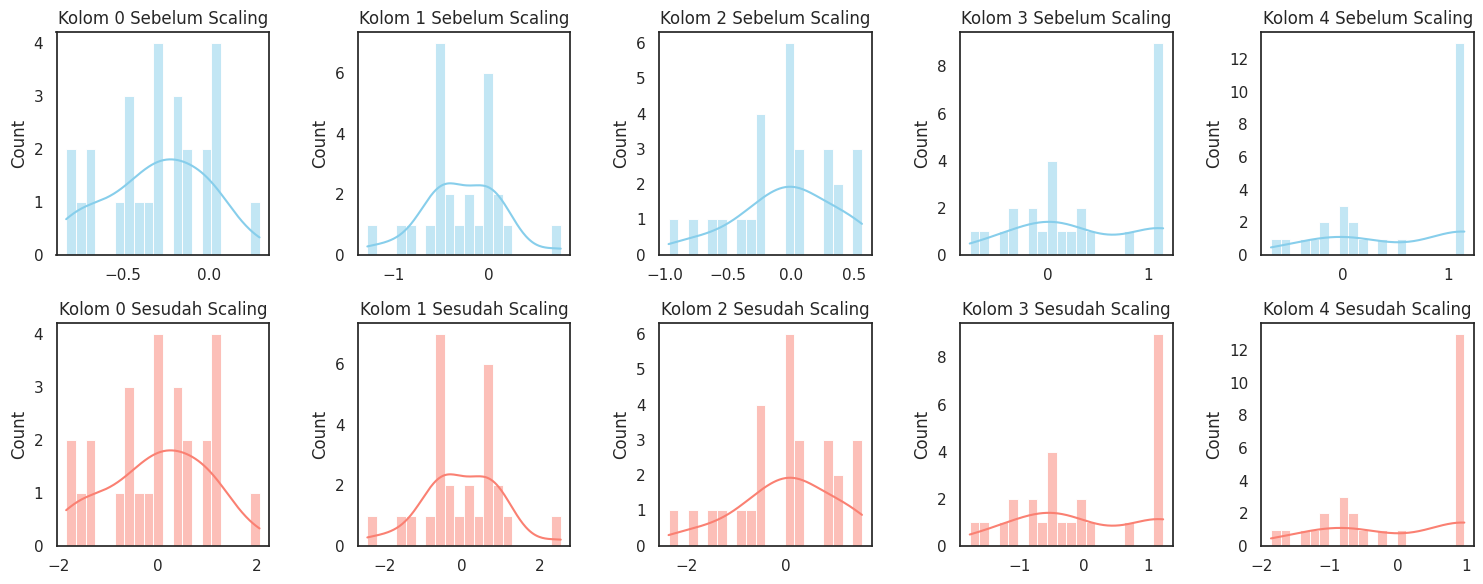

In [90]:
# ============================================================
# Visualisasi Scaling
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Anggap X_train_clean dan X_train_scaled sudah ada

# Pilih beberapa kolom untuk divisualisasikan (misal 5 kolom pertama)
cols_to_plot = range(min(5, X_train_clean.shape[1]))

plt.figure(figsize=(15,6))

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, len(cols_to_plot), i+1)
    sns.histplot(X_train_clean[:, col], bins=20, kde=True, color='skyblue')
    plt.title(f'Kolom {col} Sebelum Scaling')

    plt.subplot(2, len(cols_to_plot), i+1+len(cols_to_plot))
    sns.histplot(X_train_scaled[:, col], bins=20, kde=True, color='salmon')
    plt.title(f'Kolom {col} Sesudah Scaling')

plt.tight_layout()
plt.show()


### Smote

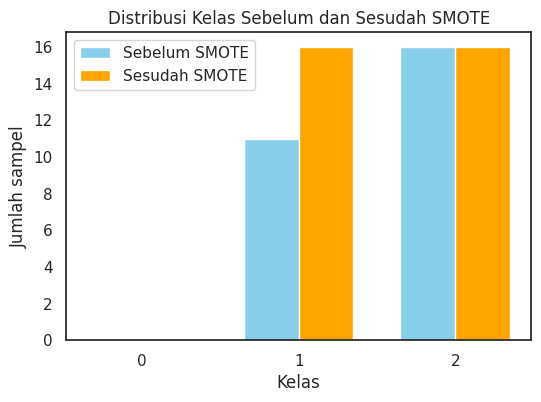

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE

# Misal X_train_scaled dan y_train_raw sudah ada

# Terapkan SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_raw)

# Hitung distribusi kelas
classes_before = np.bincount(y_train_raw)
classes_after = np.bincount(y_train_balanced)
labels = [str(i) for i in range(len(classes_after))]  # label kelas

# Visualisasi
fig, ax = plt.subplots(figsize=(6,4))
width = 0.35
x = np.arange(len(labels))
ax.bar(x - width/2, classes_before, width, label='Sebelum SMOTE', color='skyblue')
ax.bar(x + width/2, classes_after, width, label='Sesudah SMOTE', color='orange')

ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah sampel')
ax.set_title('Distribusi Kelas Sebelum dan Sesudah SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()


### Data untuk model

In [93]:
print("Shape X_train untuk KNN:", X_train_scaled.shape)
print("Shape X_test  untuk KNN:", X_test_scaled.shape)


Shape X_train untuk KNN: (27, 65)
Shape X_test  untuk KNN: (953, 65)


### Reduksi Dimensi Fitur Time Series menggunakan Principal Component Analysis (PCA)

Principal Component Analysis (PCA) untuk mereduksi dimensi data sensor dari 65 fitur menjadi sejumlah komponen utama yang tetap mempertahankan sebagian besar variasi data, sehingga mempermudah dan menstabilkan proses klasifikasi pada model KNN, SVM, atau Random Forest.”

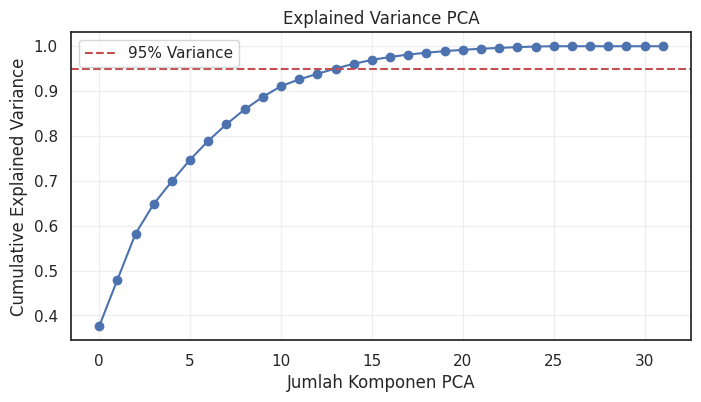

PCA selesai.
Shape X_train_pca: (32, 20)
Shape X_test_pca : (953, 20)
Total explained variance: 0.9890573504370749
PCA disimpan sebagai 'pca_model.pkl'


In [94]:
# ============================================================
# BLOK PCA: Dimensionality Reduction setelah SMOTE
# Input  : X_train_balanced, X_test_scaled
# Output : X_train_pca, X_test_pca
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

# ============================
# 1️⃣ Analisis Explained Variance pada TRAIN HASIL SMOTE
# ============================
pca_temp = PCA()
pca_temp.fit(X_train_balanced)  # ← gunakan data train hasil SMOTE

explained_variance = np.cumsum(pca_temp.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(explained_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================
# 2️⃣ Tentukan jumlah komponen
# ============================
n_components = 20  # sesuaikan dengan grafik

# ============================
# 3️⃣ Terapkan PCA
# ============================
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_balanced)  # TRAIN hasil SMOTE
X_test_pca  = pca.transform(X_test_scaled)         # TEST tetap dari X_test_scaled

print("PCA selesai.")
print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca :", X_test_pca.shape)

# ============================
# 4️⃣ Informasi PCA
# ============================
total_variance = np.sum(pca.explained_variance_ratio_)
print("Total explained variance:", total_variance)

# ============================
# 5️⃣ Simpan PCA
# ============================
joblib.dump(pca, "pca_model.pkl")
print("PCA disimpan sebagai 'pca_model.pkl'")


## Pemodelan Data

### Pemilihan Model Terbaik

KNN: F1-macro CV mean = 0.8723
Random Forest: F1-macro CV mean = 0.8749
AdaBoost: F1-macro CV mean = 0.8441

Model terbaik yang digunakan: KNN

--- KNN ---
              precision    recall  f1-score   support

           1       0.71      0.82      0.76       365
           2       0.88      0.79      0.83       588

    accuracy                           0.80       953
   macro avg       0.79      0.81      0.80       953
weighted avg       0.81      0.80      0.80       953



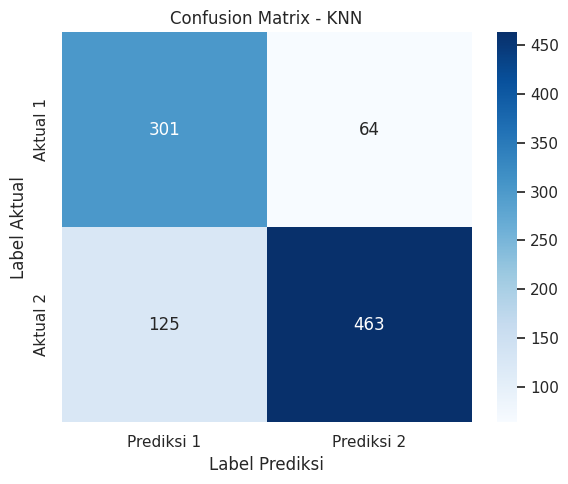

--- Random Forest ---
              precision    recall  f1-score   support

           1       0.68      0.88      0.77       365
           2       0.91      0.74      0.82       588

    accuracy                           0.79       953
   macro avg       0.79      0.81      0.79       953
weighted avg       0.82      0.79      0.80       953



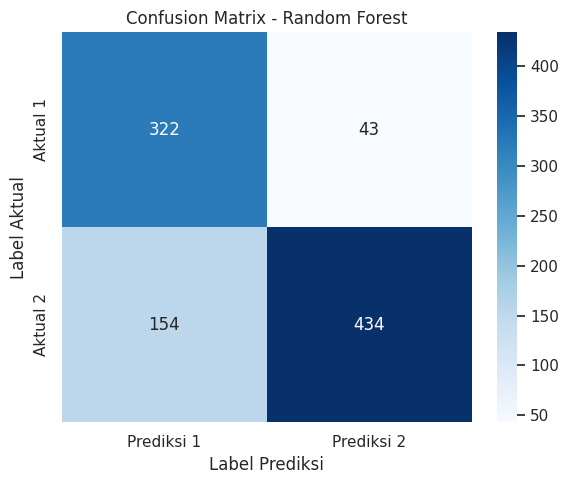

--- AdaBoost ---
              precision    recall  f1-score   support

           1       0.64      0.81      0.72       365
           2       0.86      0.71      0.78       588

    accuracy                           0.75       953
   macro avg       0.75      0.76      0.75       953
weighted avg       0.78      0.75      0.76       953



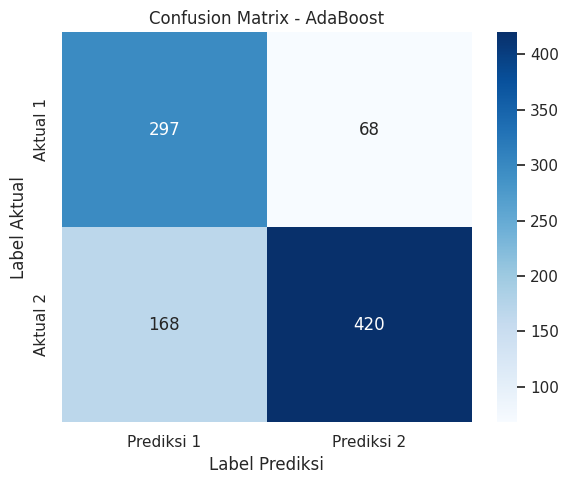

Model terbaik untuk aplikasi robot (test set stabil): KNN


In [95]:
# ============================================================
# PIPELINE: Heatmap Confusion Matrix tiap model + KNN sebagai Best Model
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score

# ============================
# 1️⃣ Definisikan kandidat model
# ============================
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

# ============================
# 2️⃣ Evaluasi tiap model dengan CV (F1-macro)
# ============================
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_pca, y_train_balanced, cv=3, scoring='f1_macro')
    cv_results[name] = scores.mean()
    print(f"{name}: F1-macro CV mean = {scores.mean():.4f}")

# ============================
# 3️⃣ Tentukan model terbaik 
# ============================
best_model_name = "KNN"
best_model = models[best_model_name]
print(f"\nModel terbaik yang digunakan: {best_model_name}\n")

# ============================
# 4️⃣ Latih tiap model & tampilkan heatmap
# ============================
for name, model in models.items():
    model.fit(X_train_pca, y_train_balanced)
    y_pred = model.predict(X_test_pca)
    
    print(f"--- {name} ---")
    print(classification_report(y_test_raw, y_pred))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test_raw, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Prediksi 1','Prediksi 2'],
        yticklabels=['Aktual 1','Aktual 2']
    )
    plt.xlabel('Label Prediksi')
    plt.ylabel('Label Aktual')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

# ============================
# 5️⃣ Tampilkan model terbaik di paling bawah
# ============================
print(f"Model terbaik untuk aplikasi robot (test set stabil): {best_model_name}")


### Melatih Model Menggunakan KNN

In [96]:
# ============================================================
#  Latih KNN + Evaluasi + Heatmap
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
import joblib

# ============================
# 1️⃣ Tentukan model KNN terbaik
# ============================
best_model = KNeighborsClassifier(n_neighbors=3, metric='cosine', weights='distance') #menggunakan perhitungan metric cosine
print("Model KNN siap dilatih.")

# ============================
# 2️⃣ Latih model pada data TRAIN hasil SMOTE + PCA
# ============================
best_model.fit(X_train_pca, y_train_balanced)
print("Model KNN berhasil dilatih.")

# ============================
# 3️⃣ Prediksi data TEST
# ============================
y_test_pred = best_model.predict(X_test_pca)
print("Prediksi data test selesai.")

# ============================
# Simpan model final
# ============================
joblib.dump(best_model, "KNN_final_model.pkl")
print("Model KNN disimpan sebagai 'KNN_final_model.pkl'.")


Model KNN siap dilatih.
Model KNN berhasil dilatih.
Prediksi data test selesai.
Model KNN disimpan sebagai 'KNN_final_model.pkl'.


## Evaluasi Model

Akurasi test set: 84.26%
Confusion Matrix:
 [[311  54]
 [ 96 492]]
Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.85      0.81       365
           2       0.90      0.84      0.87       588

    accuracy                           0.84       953
   macro avg       0.83      0.84      0.84       953
weighted avg       0.85      0.84      0.84       953



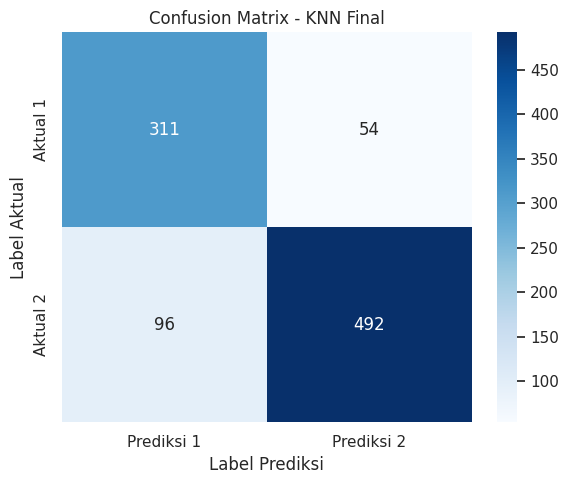

Error rate kelas 0: 14.79%
Error rate kelas 1: 16.33%


In [97]:
# ============================================================
# BLOK EVALUASI MODEL FINAL: KNN
# Input  : y_test_raw, y_test_pred (hasil prediksi KNN final)
# Output : Akurasi, Confusion Matrix, Classification Report, Visualisasi
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================
# 1️⃣ Akurasi test set
# ============================
accuracy = accuracy_score(y_test_raw, y_test_pred)
print(f"Akurasi test set: {accuracy*100:.2f}%")

# ============================
# 2️⃣ Confusion Matrix
# ============================
cm = confusion_matrix(y_test_raw, y_test_pred)
print("Confusion Matrix:\n", cm)

# ============================
# 3️⃣ Classification Report
# ============================
cr = classification_report(y_test_raw, y_test_pred)
print("Classification Report:\n", cr)

# ============================
# 4️⃣ Visualisasi Confusion Matrix (Heatmap)
# ============================
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi 1','Prediksi 2'],
            yticklabels=['Aktual 1','Aktual 2'])
plt.title('Confusion Matrix - KNN Final')
plt.xlabel('Label Prediksi')
plt.ylabel('Label Aktual')
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================
# 5️⃣ Analisis Error per Kelas (opsional)
# ============================
error_per_class = 1 - np.diag(cm)/np.sum(cm, axis=1)
for idx, err in enumerate(error_per_class):
    print(f"Error rate kelas {idx}: {err*100:.2f}%")


## Deployment

### Tampilan UI Streamlit

In [ ]:
# ============================================================
# STREAMLIT APP: KNN Robot Surface Classifier (Dinamis)
# ============================================================

import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ----------------------------
# 1️⃣ Page Config
# ----------------------------
st.set_page_config(
    page_title="Robot Surface Classifier",
    layout="wide"
)

# ----------------------------
# 2️⃣ Custom CSS untuk font & icon
# ----------------------------
st.markdown("""
<style>
@import url('https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css');

h1 {
    font-family: 'Arial', sans-serif;
    font-size: 38px;
    text-align: center;
    color: #1F77B4;
}
h2 {
    font-family: 'Arial', sans-serif;
    font-size: 24px;
    text-align: center;
    color: #333333;
}
p {
    font-family: 'Arial', sans-serif;
    font-size: 16px;
    text-align: center;
    color: #555555;
}
</style>
""", unsafe_allow_html=True)

# ----------------------------
# 3️⃣ Title & Intro dengan icon FontAwesome
# ----------------------------
st.markdown("<h1><i class='fa fa-robot'></i> Robot Surface Classification (KNN)</h1>", unsafe_allow_html=True)
st.markdown("<p>Deteksi permukaan robot: Licin vs Kasar</p>", unsafe_allow_html=True)
st.markdown("<p style='text-align:center;'><span style='background-color:#E0F7FA; padding:5px 10px; border-radius:5px;'>Pipeline: StandardScaler → PCA → KNN (cosine, weights='distance')</span></p>", unsafe_allow_html=True)

st.markdown("---")
st.markdown("<h2>📁 Upload CSV File</h2>", unsafe_allow_html=True)
st.markdown("<p>File CSV harus memiliki <b>65 fitur getaran</b>. Kolom <b>label</b> opsional untuk evaluasi.</p>", unsafe_allow_html=True)

# ----------------------------
# 4️⃣ Upload CSV
# ----------------------------
uploaded_file = st.file_uploader("Upload CSV file here", type="csv")

if uploaded_file:
    data = pd.read_csv(uploaded_file)
    st.write("Preview data:")
    st.dataframe(data.head())

    # ----------------------------
    # Pisahkan fitur & label
    # ----------------------------
    if "label" in data.columns:
        X_raw = data.drop(columns=["label"]).values
        y_true = data["label"].values
    else:
        X_raw = data.values
        y_true = None

    # ----------------------------
    # Scaling & PCA
    # ----------------------------
    scaler = joblib.load("scaler_standard.pkl")
    X_scaled = scaler.transform(X_raw)

    pca = joblib.load("pca_model.pkl")
    X_pca = pca.transform(X_scaled)

    # ----------------------------
    # Load KNN model
    # ----------------------------
    knn_model = joblib.load("KNN_final_model.pkl")
    y_pred = knn_model.predict(X_pca)

    # ----------------------------
    # Mapping label ke nama permukaan (1 → Licin, 2 → Kasar)
    # ----------------------------
    label_mapping = {1: "Permukaan Licin", 2: "Permukaan Kasar"}

    y_pred_int = [int(i) if int(i) in label_mapping else 1 for i in y_pred]
    y_pred_labels = [label_mapping[i] for i in y_pred_int]

    if y_true is not None:
        y_true_int = [int(i) if int(i) in label_mapping else 1 for i in y_true]
        y_true_labels = [label_mapping[i] for i in y_true_int]

    # ----------------------------
    # Tampilkan mapping label
    # ----------------------------
    st.markdown("### 🔹 Label Mapping")
    st.markdown(
        f"- **1 → {label_mapping[1]}**  \n"
        f"- **2 → {label_mapping[2]}**"
    )

    # ----------------------------
    # Slider untuk pilih jumlah baris
    # ----------------------------
    num_rows = st.slider(
        "Pilih jumlah baris data yang ingin ditampilkan:",
        min_value=1,
        max_value=X_raw.shape[0],
        value=min(10, X_raw.shape[0])
    )

    # ----------------------------
    # Subset data sesuai jumlah baris
    # ----------------------------
    X_subset = X_raw[:num_rows, :]
    y_pred_subset = y_pred_labels[:num_rows]
    y_true_subset = y_true_labels[:num_rows] if y_true is not None else None

    # ----------------------------
    # Tabel prediksi
    # ----------------------------
    st.subheader(f"Tabel Prediksi Permukaan ({num_rows} baris)")

    feature_columns = [f"V{i+1}" for i in range(X_raw.shape[1])]
    df_display = pd.DataFrame(X_subset, columns=feature_columns)
    df_display["Predicted Surface"] = y_pred_subset
    if y_true_subset is not None:
        df_display["Label"] = y_true_subset

    def highlight_surface(val):
        if val == "Permukaan Licin":
            return 'background-color: lightgreen'
        elif val == "Permukaan Kasar":
            return 'background-color: lightcoral'
        else:
            return ''

    st.dataframe(df_display.style.applymap(lambda v: highlight_surface(v), subset=["Predicted Surface"]))

    # ----------------------------
    # Distribusi prediksi untuk subset
    # ----------------------------
    st.subheader("Distribusi Prediksi Permukaan (Subset Data)")
    pred_count = pd.Series(y_pred_subset).value_counts()
    col1, col2 = st.columns(2)
    with col1:
        st.bar_chart(pred_count)
    with col2:
        fig, ax = plt.subplots()
        ax.pie(pred_count, labels=pred_count.index, autopct='%1.1f%%', colors=['lightgreen','lightcoral'])
        ax.set_title("Distribusi Prediksi Permukaan")
        st.pyplot(fig)

    # ----------------------------
    # Confusion matrix & metrics (opsional)
    # ----------------------------
    if y_true is not None:
        st.subheader("Evaluasi Model (Subset Data dengan label asli)")
        cm = confusion_matrix(y_true_subset, y_pred_subset)
        st.write("Confusion Matrix:")
        st.dataframe(cm)

        fig, ax = plt.subplots(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_mapping.values(),
                    yticklabels=label_mapping.values())
        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")
        plt.title("Confusion Matrix Heatmap")
        st.pyplot(fig)

        accuracy = accuracy_score(y_true_subset, y_pred_subset)
        st.write(f"Accuracy: {accuracy*100:.2f}%")

        cr = classification_report(y_true_subset, y_pred_subset)
        st.text("Classification Report:\n" + cr)

# Footer
st.markdown("---")
st.markdown("<p style='text-align:center;'>App menggunakan model <b>KNN</b> dengan preprocessing <b>StandardScaler → PCA → KNN</b>.</p>", unsafe_allow_html=True)


### Link Web Streamlit

https://4yjksdadcnk5mvjru2xzxw.streamlit.app/